---
numbering: false
---

# 10.3. The Best Direction

## Introduction

As we saw in [Chapter 10.2](./02-low-rank-approximation.ipynb), the singular value decomposition of a matrix $X$ into $X = U \Sigma V^T$ can be used to find the best low-rank approximation of $X$, which has applications in image compression, for example. But, hiding in the singular value decomposition is another, more data-driven application: **dimensionality reduction**.

Consider, for example, the dataset below. Each row corresponds to a penguin.

In [1]:
import seaborn as sns
penguins = sns.load_dataset('penguins').dropna()
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


Each penguin has three categorical features - `species`, `island`, and `sex` - and four numerical features - `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, and `body_mass_g`. If we restrict our attention to these numerical features, we have a $333 \times 4$ matrix, which we can think of as 333 points in $\mathbb{R}^4$. We, of course, can't visualize in $\mathbb{R}^4$. One solution is to draw scatter plots of all pairs of numerical features. Points are colored by `species`.

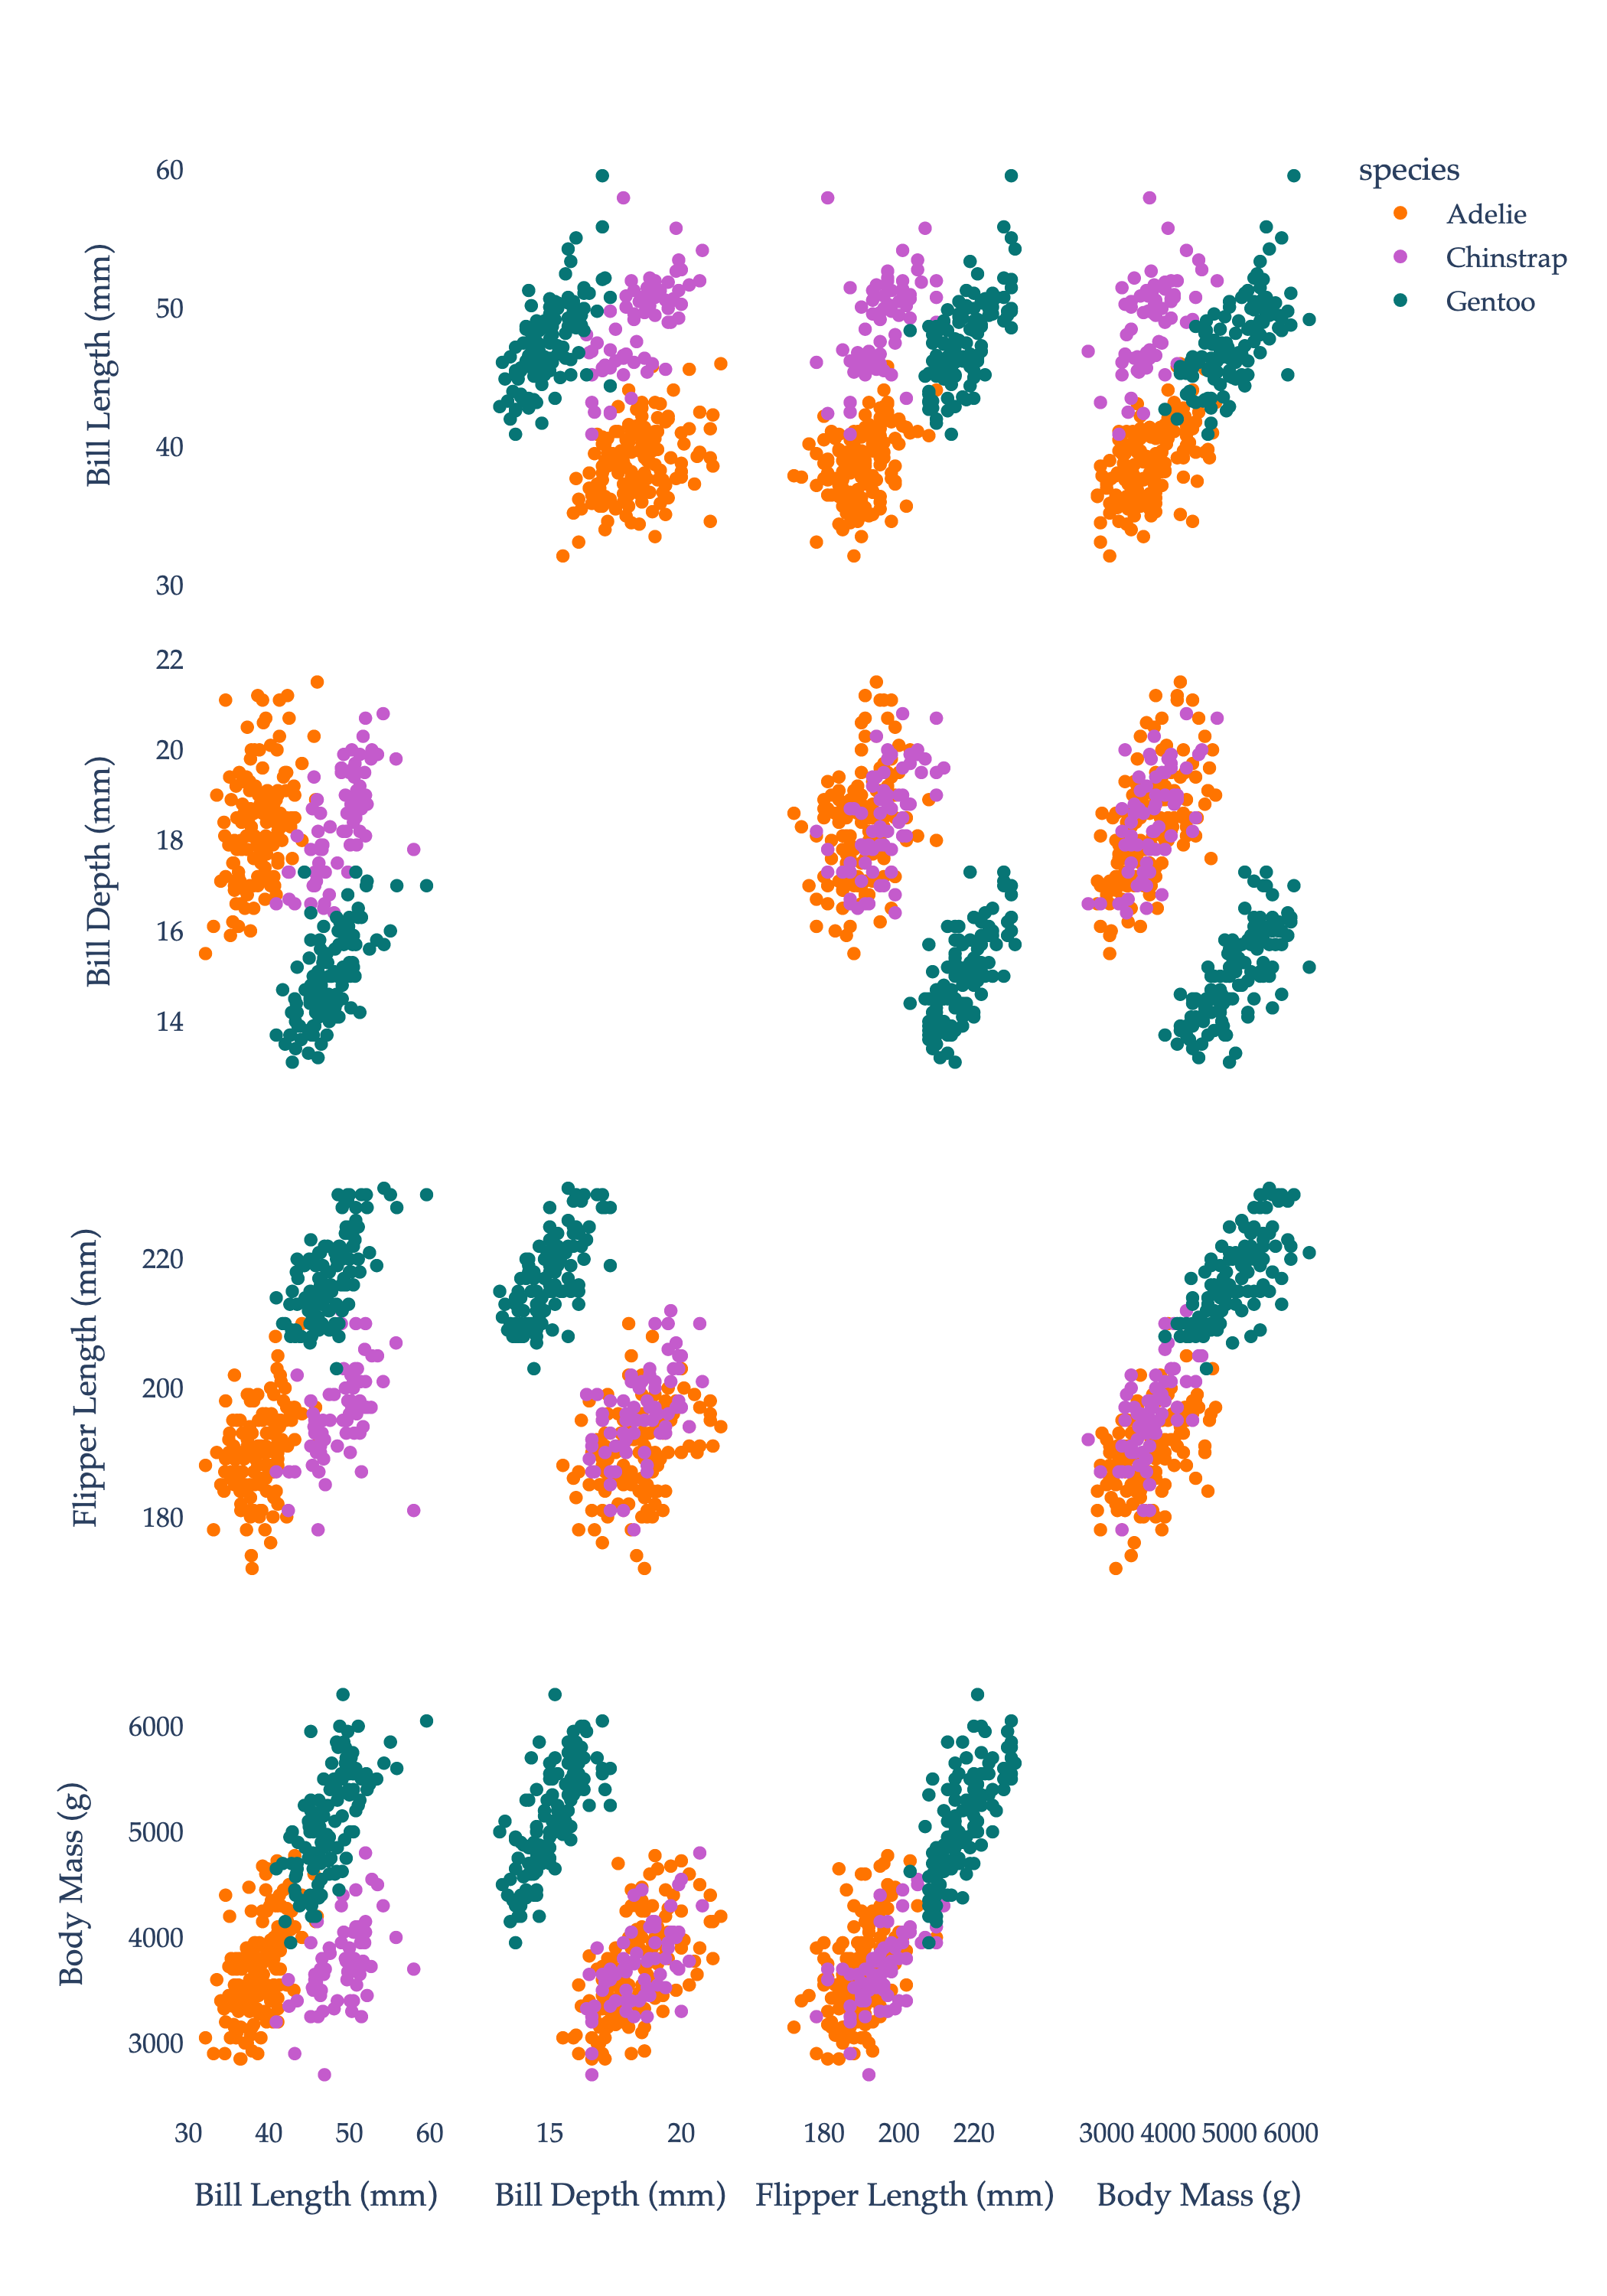

In [2]:
import plotly.express as px

numeric_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Custom color mapping for species
species_color_map = {
    'Adelie': '#ff7400',
    'Chinstrap': '#c45bcc',
    'Gentoo': '#077575'
}

fig = px.scatter_matrix(
    penguins,
    dimensions=numeric_features,
    color='species',
    labels={
        'bill_length_mm': 'Bill Length (mm)',
        'bill_depth_mm': 'Bill Depth (mm)',
        'flipper_length_mm': 'Flipper Length (mm)',
        'body_mass_g': 'Body Mass (g)'
    },
    color_discrete_map=species_color_map,
)

fig.update_traces(diagonal_visible=False)
fig.update_layout(
    height=1000,
    font_family="Palatino",
    paper_bgcolor="white",
    plot_bgcolor="white",
)

# Set axis background and major/minor gridline colors, and font for axes
# fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor="#f0f0f0", zeroline=False, showline=True, linecolor="#ccc", ticks="outside", tickfont_family="Palatino")
# fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor="#f0f0f0", zeroline=False, showline=True, linecolor="#ccc", ticks="outside", tickfont_family="Palatino")

fig.show(renderer='png', scale=3)


While we have four features (or "independent" variables) for each penguin, it seems that some of the features are strongly correlated, in the sense that the correlation coefficient

$$r = \frac{1}{n} \sum_{i=1}^n \left( \frac{x_i - \bar{x}}{\sigma_x} \right) \left( \frac{y_i - \bar{y}}{\sigma_y} \right)$$

between them is close to $\pm 1$. (To be clear, the coloring of the points is by `species`, which does not impact the correlations between features.)

In [3]:
penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


For instance, the correlation between `flipper_length_mm` and `body_mass_g` is about $0.87$, which suggests that penguins with longer flippers tend to be heavier. Not only are correlated features redundant, but they can cause interpretability issues - that is, multicollinearity - when using them in a linear regression model, since the resulting optimal parameters $\vec w^*$ will no longer be interpretable. (Remember, in $h(\vec x_i) = \vec w \cdot \text{Aug}(\vec x_i)$, $\vec w^*$ contains the optimal coefficients for each feature, which measure rates of change when the other features are held constant. But if two features are correlated, one can't be held constant without also changing the other.)

**Here's the key idea**: instead of having to work with $d = 4$ features, perhaps we can instead **construct** some number $k < d$ of **new** features that:
1. capture the "most important" information in the dataset,
2. while being **uncorrelated** (i.e. linearly independent) from one another.

I'm not suggesting that we just select some of the original features and drop the others; rather, I'm proposing that we find 1 or 2 new features that are **linear combinations** of the original features. If everything works out correctly, we may be able to **reduce the number of features** we need to deal with, without losing too much information, and without the interpretability issues that come with multicollinearity.

To illustrate what I mean by constructing a new feature, let's suppose we're starting with a 2-dimensional dataset, which we'd like to reduce to 1 dimension. Consider the scatter plot below of `flipper_length_mm` vs. `body_mass_g` (with colors removed).

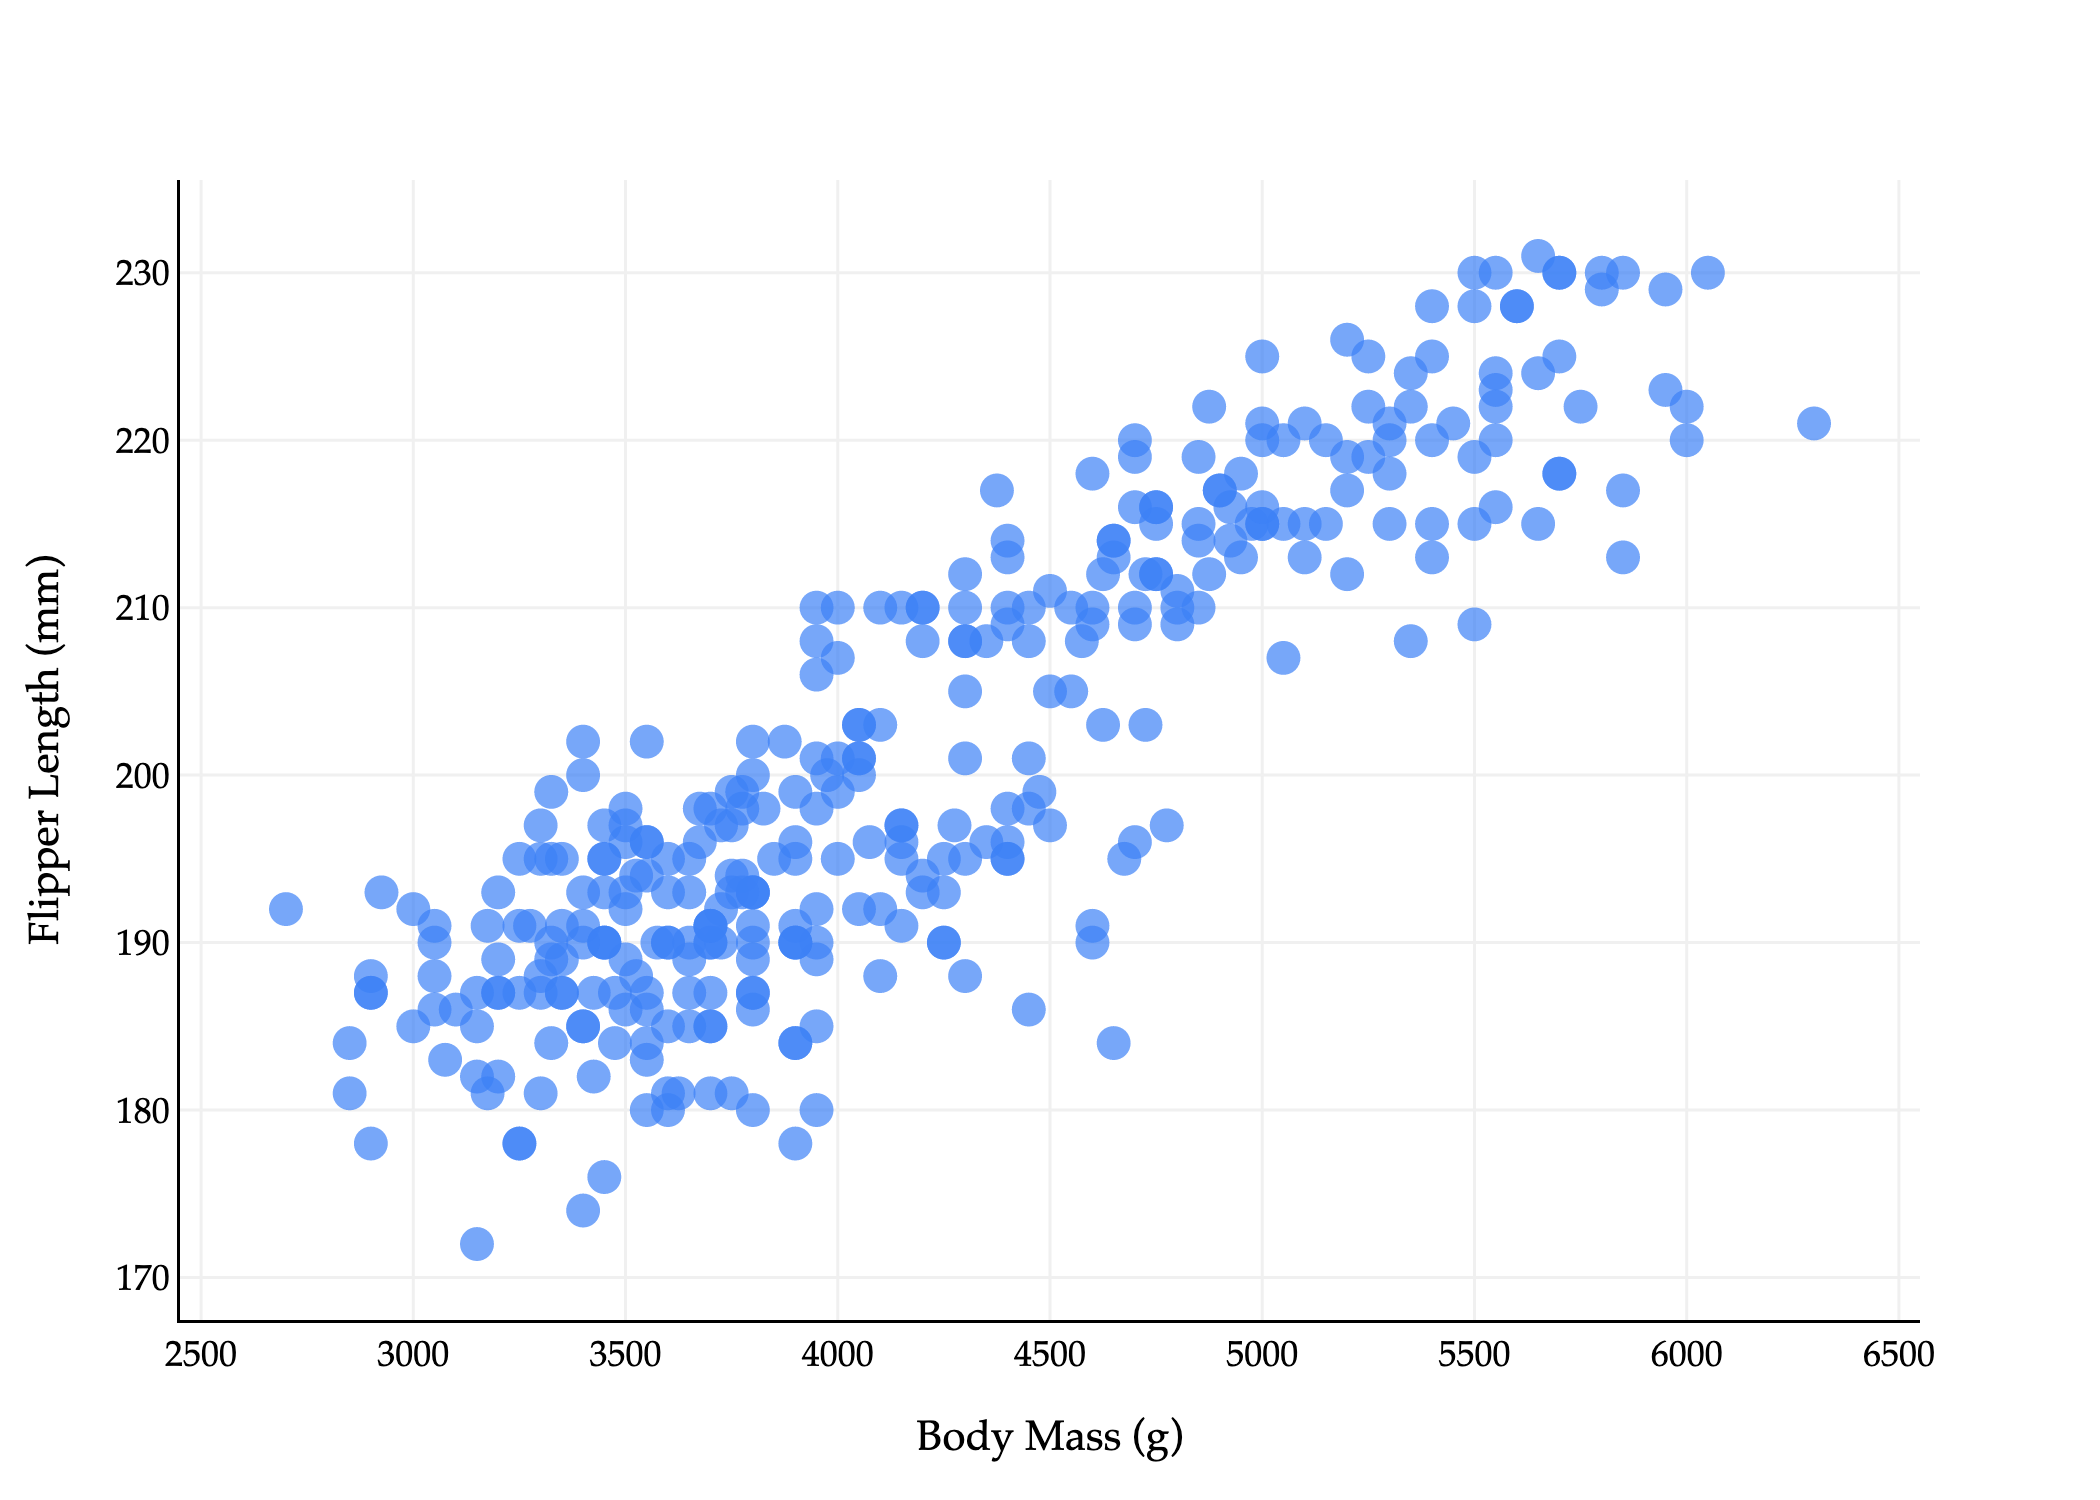

In [4]:
import plotly.express as px
import numpy as np

fig = px.scatter(
    penguins,
    x='body_mass_g',
    y='flipper_length_mm',
    size=np.ones(len(penguins)) * 50,
    size_max=8,
    labels={
        "flipper_length_mm": "Flipper Length (mm)",
        "body_mass_g": "Body Mass (g)"
    }
)
fig.update_xaxes(
    title='Body Mass (g)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    title='Flipper Length (mm)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_traces(marker_color="#3D81F6", marker_line_width=0)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)
fig.show(renderer='png', scale=3)


Above, each penguin is represented by two numbers, which we can think of as a vector $$\vec x_i = \begin{bmatrix} \text{body mass}_i \\ \text{flipper length}_i \end{bmatrix}$$

The fact that each point is a vector is not immediately intuitive given the plot above: I want you to imagine drawing arrows from the origin to each point.

Now, suppose these vectors $\vec x_i$ are in the rows of a matrix $X$, i.e.

$$X = \begin{bmatrix}
\text{body mass}_1 & \text{flipper length}_1 \\
\text{body mass}_2 & \text{flipper length}_2 \\
\vdots & \vdots \\
\text{body mass}_n & \text{flipper length}_n
\end{bmatrix}$$

Our goal is to construct a single new feature, called a **principal component**, by taking a linear combination of both existing features. **Principal component analysis**, or **PCA**, is the process of finding the best principal components (new features) for a dataset. 

$$\text{new feature}_i = a \cdot \text{body mass}_i + b \cdot \text{flipper length}_i$$

This is equivalent to approximating this 2-dimensional dataset with a single line. (The equation above is a re-arranged version of $y = mx + b$, where $x$ is $\text{body mass}_i$ and $y$ is $\text{flipper length}_i$.)

**What is the _best_ linear combination of the features, or equivalently, what is the best line to approximate this 2-dimensional dataset?** To make this idea precise, we need to define what we mean by "best". It may be tempting to think that we should find the best-fitting line that predicts `flipper_length_mm` from `body_mass_g`, but that's not quite what we want, since **this is not a prediction problem: it's a representation problem**. Regression lines in the way we've seen them before are fit by minimizing mean squared **vertical** error, $y_i - h(x_i)$, but don't at all capture horizontal errors, i.e. errors in the `body_mass_g` direction here.

So instead, we'd like to find the line such that, for our $n$ vectors (points) $\vec x_1, \ldots, \vec x_n$, the mean squared **distance to the closest vector (point) on the line** is minimized. Crucially, this distance is calculated by computing the norm of the difference between the two vectors. If $\vec p_i$ is the closest vector (point) on the line to $\vec x_i$, then we'd like to minimize

$$\frac{1}{n} \sum_{i=1}^n \lVert \vec x_i - \vec p_i \rVert^2$$

But, as we saw in [Chapter 3.4](../03_vectors/04-projecting-onto-a-single-vector.ipynb), the vector (point) on a line that is closest to another vector (point) $\vec x_i$ is the **orthogonal projection** of $\vec x_i$ onto that line. The resulting error vectors are orthogonal to the line we're projecting on. As such, I'll say that we're looking for the line that minimizes the mean squared **orthogonal projection** error.

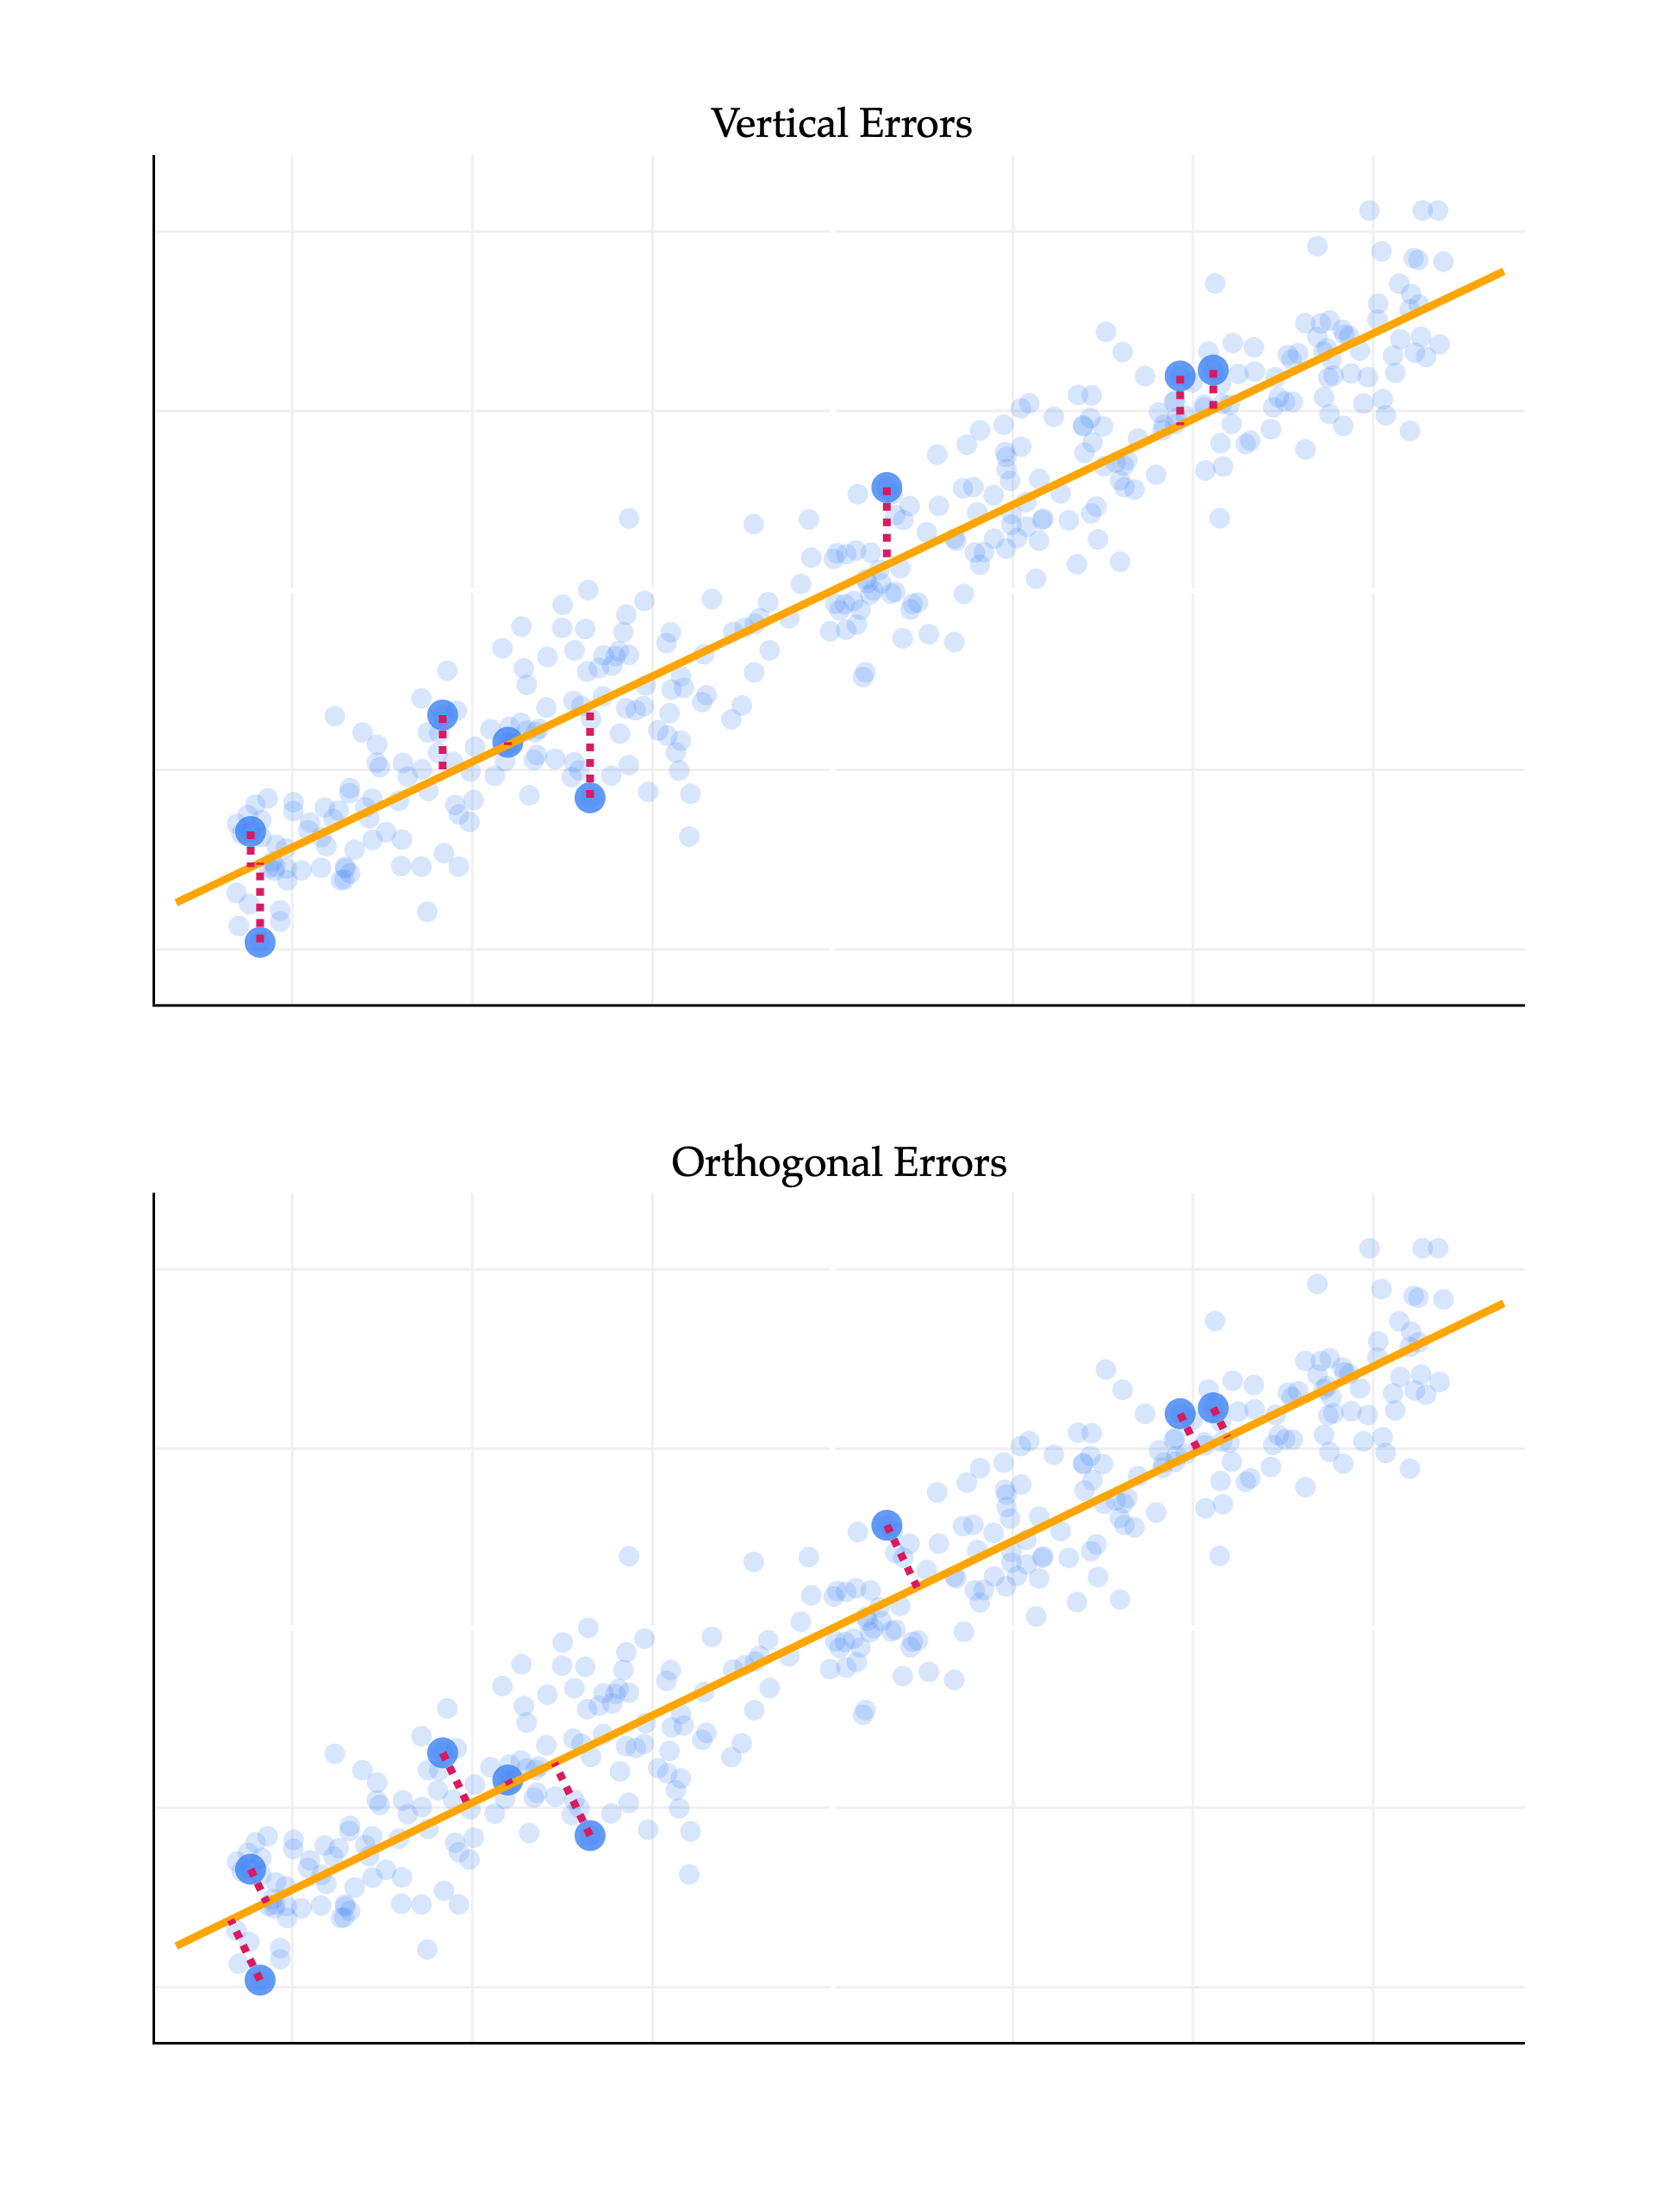

In [6]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

# --- DATA GENERATION (Synthetic Data) ---
# Using synthetic data as the external 'penguins' dataset was inaccessible.
np.random.seed(42)
num_points = 340
body_mass_g = np.random.uniform(2700, 6300, num_points)
m_true = 0.015
c_true = 120
noise = np.random.normal(0, 5, num_points)
flipper_length_mm = m_true * body_mass_g + c_true + noise

df = pd.DataFrame({
    'body_mass_g': body_mass_g,
    'flipper_length_mm': flipper_length_mm
})

# --- STANDARDIZATION ---
# Standardize both columns to mean=0, std=1
for col in ['body_mass_g', 'flipper_length_mm']:
    mean = df[col].mean()
    std = df[col].std()
    df[col + '_std'] = (2 if col == 'body_mass_g' else 1) * (df[col] - mean) / std 

data_2d = df[['body_mass_g_std', 'flipper_length_mm_std']].values

# --- MODEL FITTING on standardized data ---
# Linear Regression (still fit flipper_length_mm_std ~ body_mass_g_std)
lin_reg = LinearRegression()
lin_reg.fit(df[['body_mass_g_std']], df['flipper_length_mm_std'])
m_lr = lin_reg.coef_[0]
c_lr = lin_reg.intercept_

# PCA
pca = PCA(n_components=1)
pca.fit(data_2d)
v1 = pca.components_[0]
mean_data = pca.mean_

# --- SELECTION & RANGE ---
random_indices = np.random.choice(df.index, size=8, replace=False)
random_points = df.iloc[random_indices]

x_min, x_max = df['body_mass_g_std'].min(), df['body_mass_g_std'].max()
x_padding = (x_max - x_min) * 0.05
x_range = np.array([x_min - x_padding, x_max + x_padding])

# --- CALCULATIONS: LINEAR REGRESSION (Top Plot) ---
y_lr_line = m_lr * x_range + c_lr
lr_errors = []
for i in random_indices:
    x_i, y_i = df.loc[i, 'body_mass_g_std'], df.loc[i, 'flipper_length_mm_std']
    y_hat = m_lr * x_i + c_lr
    # Vertical error segment: (x_i, y_i) to (x_i, y_hat)
    lr_errors.append(go.Scatter(
        x=[x_i, x_i, None],
        y=[y_i, y_hat, None],
        mode='lines',
        line=dict(color='#d81a60', width=3, dash='dot'),
        showlegend=False,
        hoverinfo='none'
    ))

# --- CALCULATIONS: PCA (Bottom Plot) ---
# Parametric line points
t_min = (x_range.min() - mean_data[0]) / v1[0]
t_max = (x_range.max() - mean_data[0]) / v1[0]
x_pca_line = np.array([mean_data[0] + t_min * v1[0], mean_data[0] + t_max * v1[0]])
y_pca_line = np.array([mean_data[1] + t_min * v1[1], mean_data[1] + t_max * v1[1]])

pca_errors = []
for idx in random_indices:
    p_i = data_2d[idx]
    projection_scalar = np.dot(p_i - mean_data, v1)
    p_tilde = mean_data + projection_scalar * v1
    # Orthogonal error segment: (p_i) to (p_tilde)
    pca_errors.append(go.Scatter(
        x=[p_i[0], p_tilde[0], None],
        y=[p_i[1], p_tilde[1], None],
        mode='lines',
        line=dict(color='#d81a60', width=3, dash='dot'),
        showlegend=False,
        hoverinfo='none'
    ))

# --- CREATE SUBPLOTS ---
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=False,
    vertical_spacing=0.1,
    subplot_titles=("Vertical Errors", "Orthogonal Errors")
)

## TOP PLOT (ROW 1): LINEAR REGRESSION
# 1. Full Scatter (Low Opacity)
fig.add_trace(go.Scatter(
    x=df['body_mass_g_std'], y=df['flipper_length_mm_std'], mode='markers',
    marker=dict(color="#3D81F6", size=8, opacity=0.2, line_width=0),
    name='All Points (LR)', showlegend=False
), row=1, col=1)

# 2. Selected Scatter (High Opacity)
fig.add_trace(go.Scatter(
    x=random_points['body_mass_g_std'], y=random_points['flipper_length_mm_std'], mode='markers',
    marker=dict(color="#3D81F6", size=12, opacity=0.8, line_width=0),
    name='Selected Points', legendgroup='selected', showlegend=True
), row=1, col=1)

# 3. Line of Best Fit
fig.add_trace(go.Scatter(
    x=x_range, y=y_lr_line, mode='lines',
    line=dict(color='orange', width=3),
    name='Line of Best Fit', legendgroup='lines', showlegend=True
), row=1, col=1)

# 4. Vertical Errors (Placeholder for Legend)
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='lines',
    line=dict(color='#d81a60', width=1.5, dash='dot'),
    name='Errors', legendgroup='errors', showlegend=True
), row=1, col=1)
for error_trace in lr_errors:
    fig.add_trace(error_trace, row=1, col=1)


## BOTTOM PLOT (ROW 2): PCA
# 1. Full Scatter (Low Opacity)
fig.add_trace(go.Scatter(
    x=df['body_mass_g_std'], y=df['flipper_length_mm_std'], mode='markers',
    marker=dict(color="#3D81F6", size=8, opacity=0.2, line_width=0),
    name='All Points (PCA)', showlegend=False
), row=2, col=1)

# 2. Selected Scatter (High Opacity)
fig.add_trace(go.Scatter(
    x=random_points['body_mass_g_std'], y=random_points['flipper_length_mm_std'], mode='markers',
    marker=dict(color="#3D81F6", size=12, opacity=0.8, line_width=0),
    name='Selected Points', legendgroup='selected', showlegend=False
), row=2, col=1)

# 3. First Principal Component Line
fig.add_trace(go.Scatter(
    x=x_pca_line, y=y_pca_line, mode='lines',
    line=dict(color='orange', width=3),
    name='First Principal Component', legendgroup='lines', showlegend=True
), row=2, col=1)

# 4. Orthogonal Errors
for error_trace in pca_errors:
    fig.add_trace(error_trace, row=2, col=1)

# --- APPLY STYLING: Equal aspect ratio for both axes in row 2 ---
common_axis_style = dict(
    title='Flipper Length (standardized)',
    gridcolor='#f0f0f0', showline=True, linecolor="black", linewidth=1,
)
fig.update_yaxes(common_axis_style, row=1, col=1)
fig.update_yaxes(common_axis_style, row=2, col=1)

fig.update_xaxes(
    title='Body Mass (standardized)', gridcolor='#f0f0f0', showline=True, linecolor="black", linewidth=1,
    row=2, col=1
)
fig.update_xaxes(
    gridcolor='#f0f0f0', showline=True, linecolor="black", linewidth=1, row=1, col=1
) # No x-axis title on top plot

# Set aspectmode='equal' for bottom plot only
fig.update_yaxes(
    scaleanchor = "x", scaleratio = 1,
    row=1, col=2,
    title=''
)
fig.update_xaxes(
    constrain='domain',
    row=2, col=1,
)

fig.update_xaxes(
    title='',
    showticklabels=False
)

fig.update_yaxes(
    title='',
    showticklabels=False
)

fig.update_layout(
    plot_bgcolor='white', paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=650, height=850,
    font=dict(family="Palatino Linotype, Palatino, serif", color="black"),
    showlegend=False
)

fig.show(renderer='png', scale=3)

The difference between the two lines above is key. The top line reflects the supervised nature of linear regression, where the goal is to make accurate predictions. The bottom line reflects the fact that we're looking for a new representation of the data that captures the most important information. These, in general, are not the same line, since they're chosen to minimize different objective functions. 

Recall from Chapter 1 that **unsupervised learning** is the process of finding structure in unlabeled data, without any specific target variable. This is precisely the problem we're trying to solve here. To further distinguish our current task from the problem of finding regression lines, I'll now refer to finding the line with minimal orthogonal projection error as finding the **best direction**.

:::{tip} Activity 1
:class: dropdown
Consider the line $\frac{3}{5}x + \frac{4}{5}y = 0$ in $\mathbb{R}^2$. For the point $(1, 1)$,
1. What is the vertical error of projecting $(1, 1)$ onto the line?
2. What is the point on the line that is closest to $(1, 1)$?
3. What is the orthogonal error of projecting $(1, 1)$ onto the line?
:::

---

## Minimizing Orthogonal Error

The first section above told us that our goal is to find the best direction, which is the direction that minimizes the mean squared orthogonal error of projections onto it. How do we find this direction? 

Fortunately, we spent all of [Chapter 3.4](../03_vectors/04-projecting-onto-a-single-vector.ipynb) and [Chapter 6.3](../06_linear_transformations_and_projections/03-projecting-onto-column-space.ipynb) discussing orthogonal projections. But there, we discussed how to project **one** vector onto the span of one or more other **given** vectors (e.g. projecting the observation vector $\vec y$ onto the span of the columns of a design matrix $X$). That's not quite we're doing here, because here, we don't know which vector we're projecting onto: we're trying to find the **best** vector to project our $n = 333$ other vectors onto!

Suppose that in general, $X$ is an $n \times d$ matrix, whose rows $\vec x_i$ are data points in $\mathbb{R}^d$. (In our current example, $d = 2$, but everything we're studying applies in higher dimensions.) Then,
- The orthogonal projection of $\vec x_i$ onto $\vec v$ is
    $$\vec p_i = \frac{\vec x_i \cdot \vec v}{\vec v \cdot \vec v} \vec v$$
- To keep the algebra slightly simpler, if we assume that $\vec v$ is a unit vector (meaning $\lVert \vec v \rVert = \sqrt{\vec v \cdot \vec v} = 1$), then the orthogonal projection of $\vec x_i$ onto $\vec v$ is
    $$\vec p_i = (\vec x_i \cdot \vec v) \vec v$$
    This is a reasonable choice to make, since unit vectors are typically used to describe directions.
- If $\vec v \in \mathbb{R}^d$, then $\text{span}(\{ \vec v \})$ is a line through the origin in $\mathbb{R}^d$.

### Centering the Data

The issue is that our dataset - and most datasets in general, by default - aren't centered at the origin, but the projections $\vec p_i = (\vec x_i \cdot \vec v) \vec v$ all lie on the line through the origin spanned by $\vec v$. So, trying to approximate our dataset using a line through the origin is not a good idea.

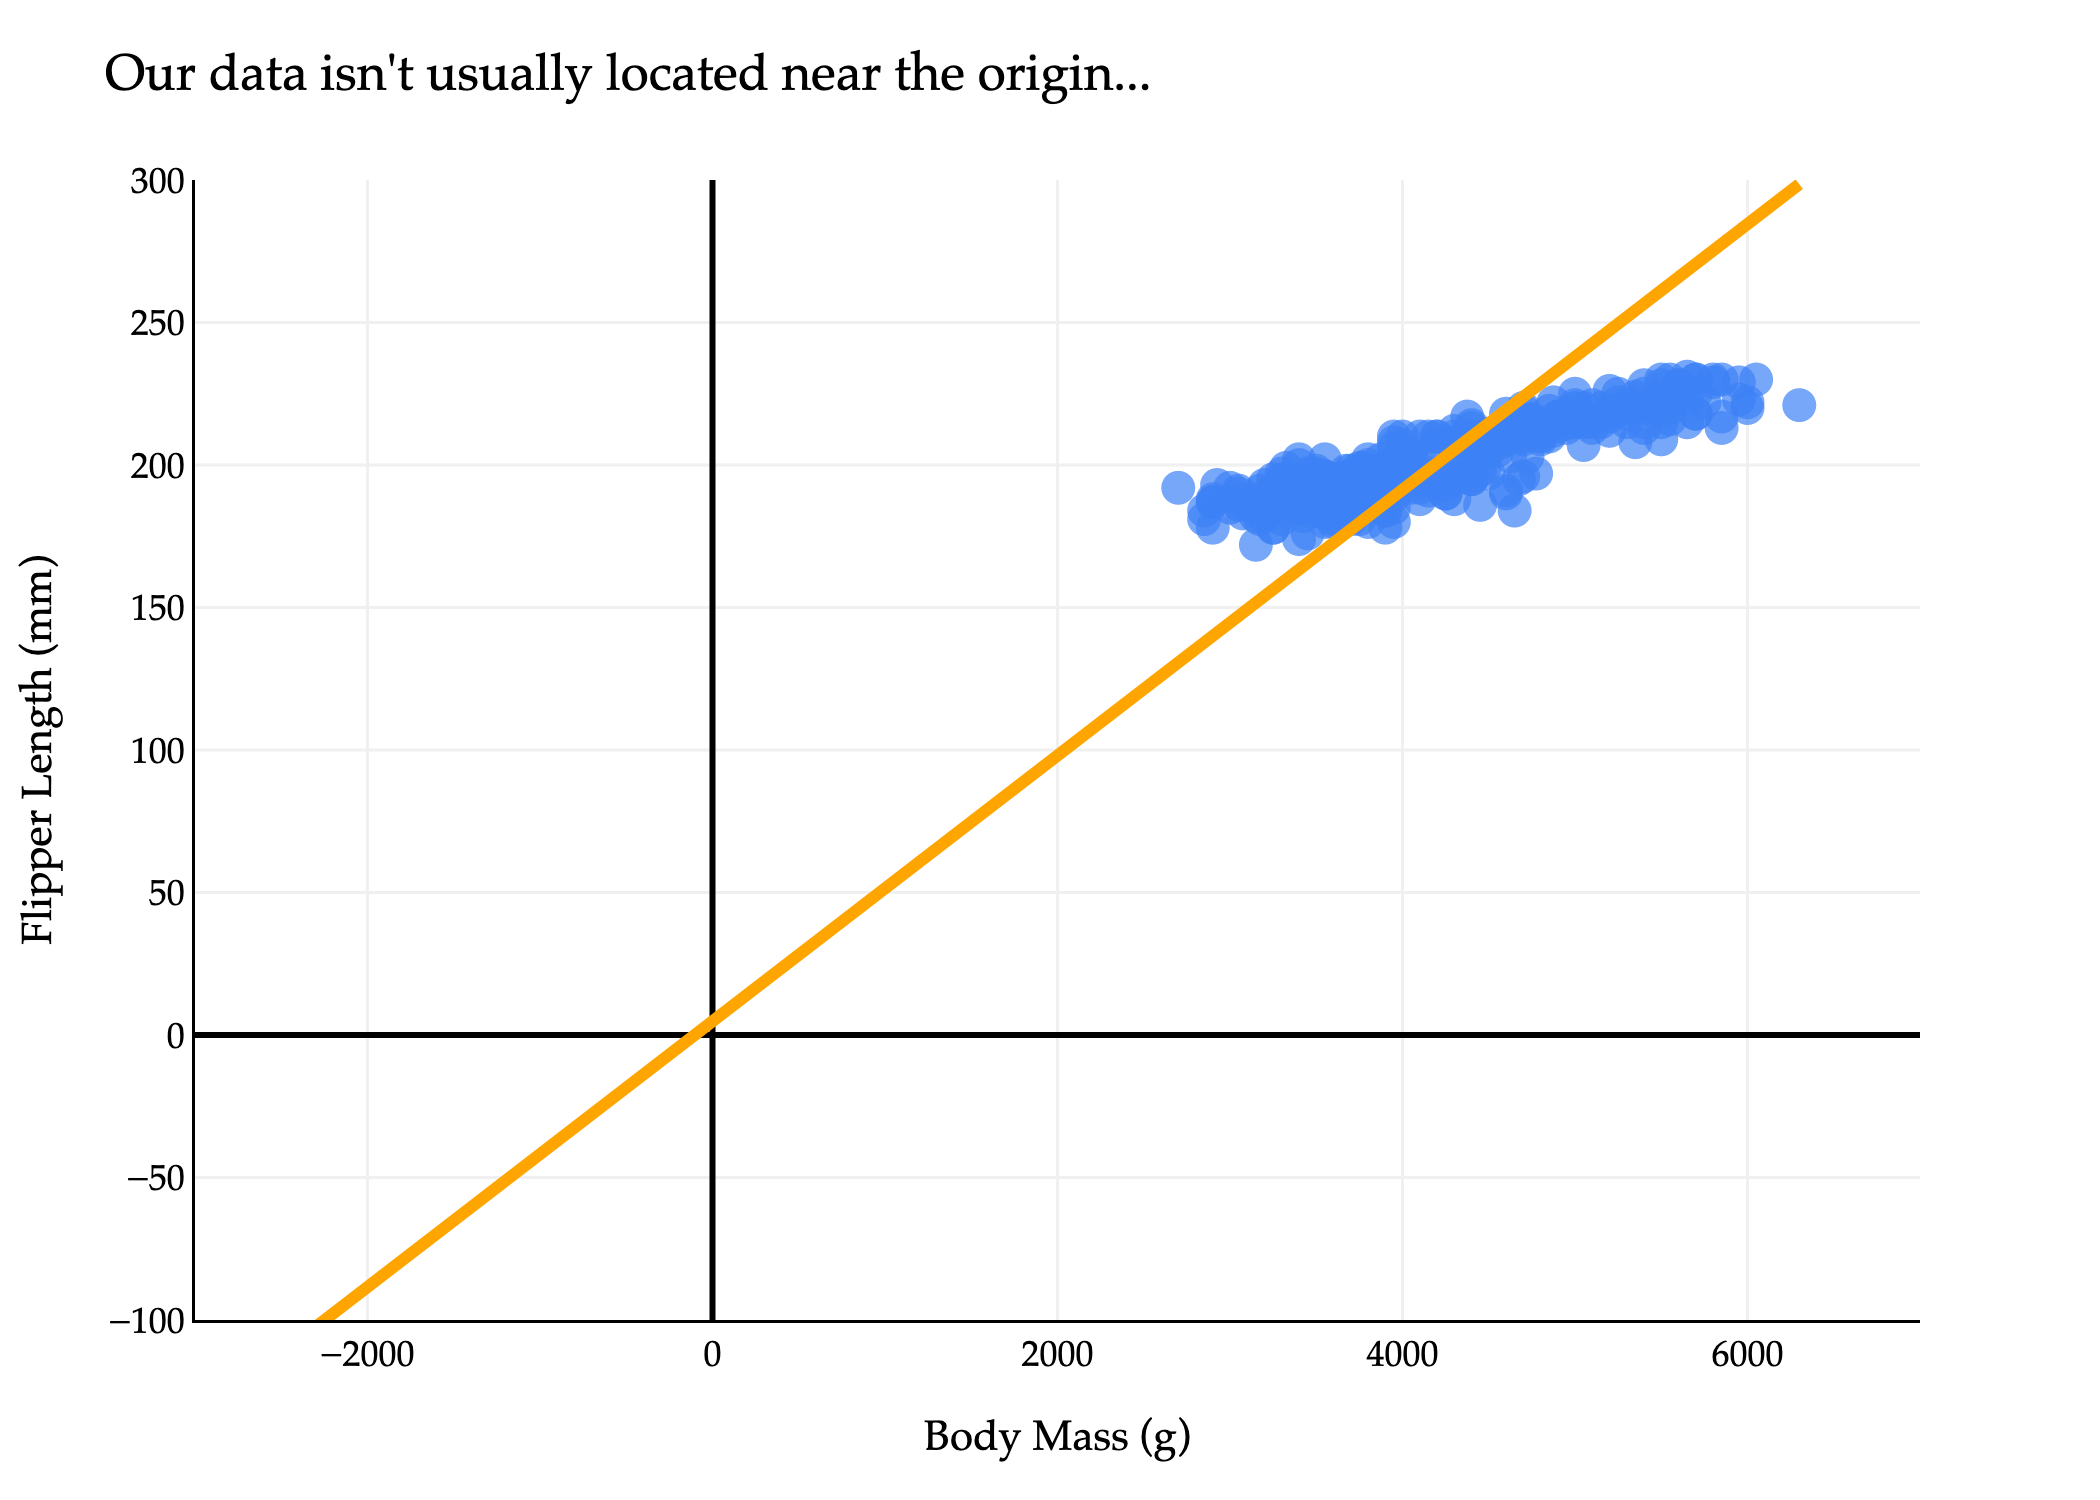

In [7]:
import plotly.express as px
import numpy as np

# Scatter plot as before
fig = px.scatter(
    penguins,
    x='body_mass_g',
    y='flipper_length_mm',
    size=np.ones(len(penguins)) * 50,
    size_max=8,
    labels={
        "flipper_length_mm": "Flipper Length (mm)",
        "body_mass_g": "Body Mass (g)"
    }
)
fig.update_xaxes(
    title='Body Mass (g)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    zeroline=True,              # Add the zeroline (x=0)
    zerolinewidth=2,
    zerolinecolor="#000"
)
fig.update_yaxes(
    title='Flipper Length (mm)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    zeroline=True,              # Add the zeroline (y=0)
    zerolinewidth=2,
    zerolinecolor="#000"
)
fig.update_traces(marker_color="#3D81F6", marker_line_width=0)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)

# --- Why doesn't the orange line pass through the origin? ---
# We are calculating the principal component direction using the uncentered data.
# That is, we use the original values of body_mass_g and flipper_length_mm,
# not values shifted so that their mean is zero.
# The line we draw to indicate the main data direction is then *anchored at the mean* of the data,
# not at the origin (0, 0).
#
# In PCA, the principal component direction is meant to describe the direction *from the center of the data*,
# not necessarily from the origin—unless the data itself has the origin as its center.

# Compute mean and principal direction from UNcentered data
X_no_center = penguins[['body_mass_g', 'flipper_length_mm']].dropna().values
mean_point = np.mean(X_no_center, axis=0)

# SVD gives principal directions, but if we don't center, the "line through the origin"
# describes how the data is spread around its mean, not around (0,0).
U, S, Vt = np.linalg.svd(X_no_center, full_matrices=False)
direction = Vt[0]
direction = direction / np.linalg.norm(direction)

# Find t values so that the orange line spans the plot regardless of origin
bm_min, bm_max = penguins['body_mass_g'].min(), penguins['body_mass_g'].max()
t0 = (-3000 - mean_point[0]) / direction[0]
t1 = (bm_max - mean_point[0]) / direction[0]
line_bm = mean_point[0] + np.array([t0, t1]) * direction[0]
line_fl = mean_point[1] + np.array([t0, t1]) * direction[1]

fig.add_traces([
    {
        "type": "scatter",
        "mode": "lines",
        "x": line_bm,
        "y": line_fl,
        "line": dict(color="orange", width=4),
        "name": "Principal Direction (uncentered)"
    }
])

fig.update_layout(
    xaxis_range=[-3000, 7000],
    yaxis_range=[-100, 300],
    showlegend=False,
    title="Our data isn't usually located near the origin..."
)
fig.show(renderer='png', scale=3)

# Explanation:
# The orange line follows the principal direction of the data, but is anchored on the mean value of 
# (body_mass_g, flipper_length_mm). Since the mean is NOT the origin (0,0), the line will not 
# pass through the origin. This illustrates why, when analyzing data directions, we almost always 
# first center the data (subtract the mean), so the principal direction can be represented as a 
# line through the origin in the transformed coordinates.


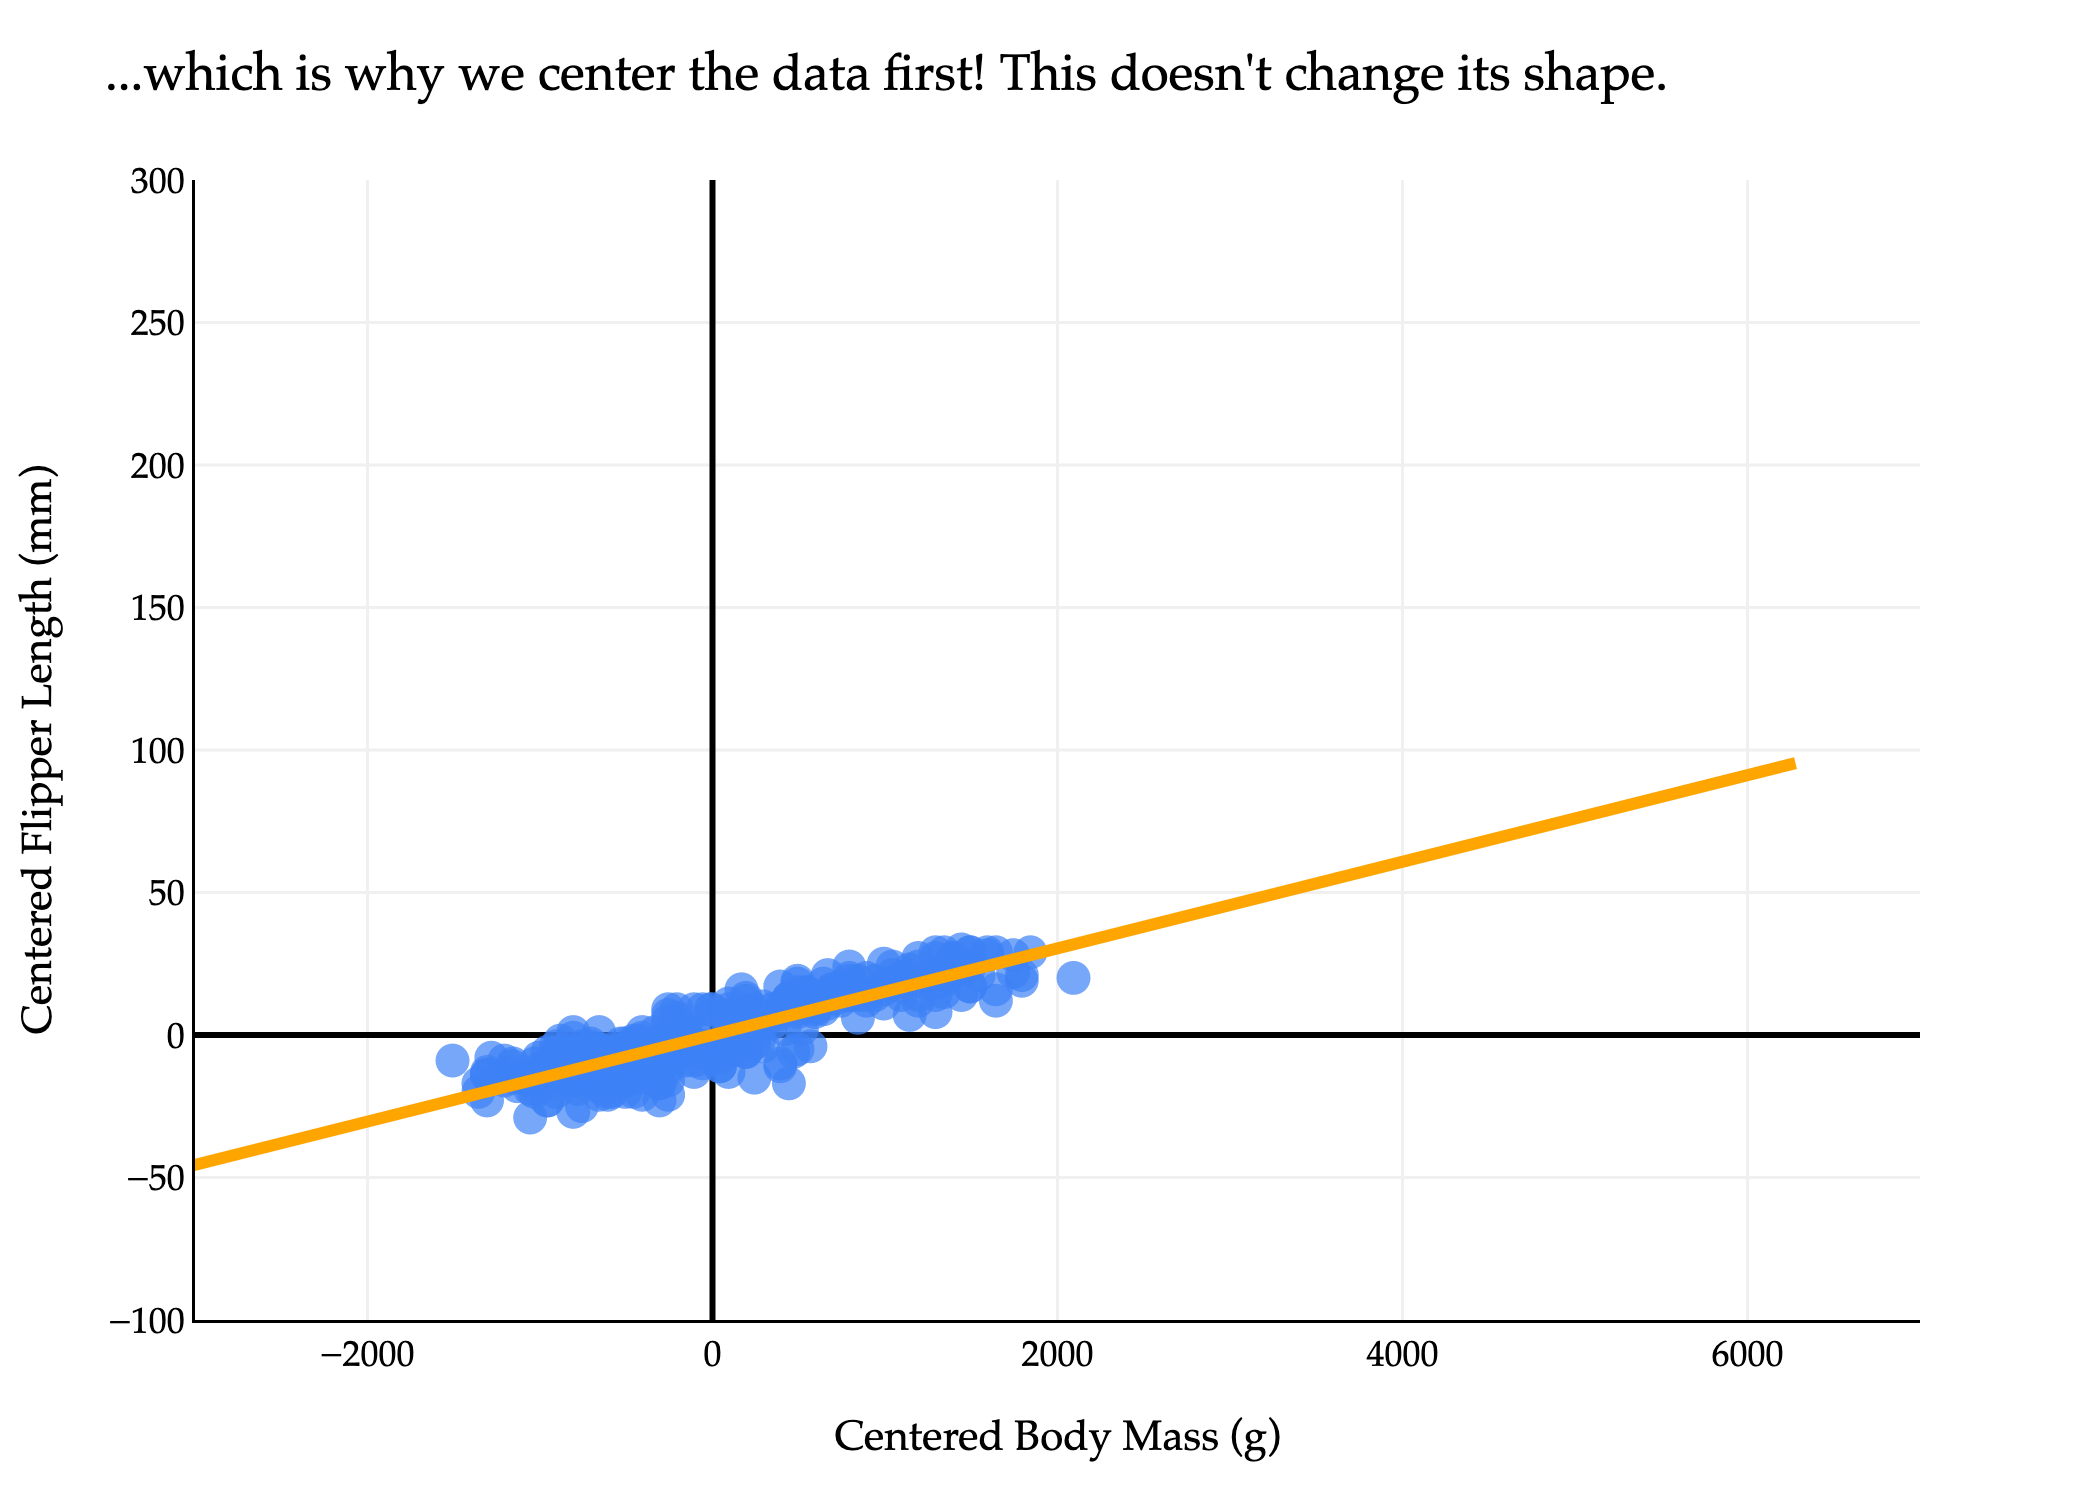

In [8]:
import plotly.express as px
import numpy as np

# Center the data
X = penguins[['body_mass_g', 'flipper_length_mm']].dropna().values
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean

# Scatter plot of centered data
fig = px.scatter(
    x=X_centered[:, 0],  # body_mass_g (centered)
    y=X_centered[:, 1],  # flipper_length_mm (centered)
    size=np.ones(len(X_centered)) * 50,
    size_max=8,
    labels={
        "x": "Body Mass (g) (centered)",
        "y": "Flipper Length (mm) (centered)"
    }
)
fig.update_xaxes(
    title='Centered Body Mass (g)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    zeroline=True,
    zerolinewidth=2,
    zerolinecolor="black",
)
fig.update_yaxes(
    title='Centered Flipper Length (mm)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    zeroline=True,
    zerolinewidth=2,
    zerolinecolor="black",
)
fig.update_traces(marker_color="#3D81F6", marker_line_width=0)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)

# --- PCA/SVD for centered data: best-fit line through origin ---
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
direction = Vt[0]
direction = direction / np.linalg.norm(direction)  # unit vector

# Draw the principal component line through the origin (since data is centered)
# We'll parametrize t over a sufficiently wide range to cover the data cloud
pc_range = 3 * np.array([
    np.min(X_centered @ direction),
    np.max(X_centered @ direction)
])
line_pts = np.outer(pc_range, direction)  # shape (2,2)

fig.add_traces([
    {
        "type": "scatter",
        "mode": "lines",
        "x": line_pts[:, 0],
        "y": line_pts[:, 1],
        "line": dict(color="orange", width=4),
        "name": "Principal Component"
    }
])

# Set axis to center zero for clarity and cover data
margin_bm = 0.1 * (X_centered[:,0].max() - X_centered[:,0].min())
margin_fl = 0.1 * (X_centered[:,1].max() - X_centered[:,1].min())
fig.update_layout(
    xaxis_range=[
        X_centered[:,0].min() - margin_bm, 
        X_centered[:,0].max() + margin_bm
    ],
    yaxis_range=[
        X_centered[:,1].min() - margin_fl, 
        X_centered[:,1].max() + margin_fl
    ],
    showlegend=False,
    title="Best-Fit PCA Line (Centered Data)"
)

fig.update_layout(xaxis_range=[-3000, 7000], yaxis_range=[-100, 300], showlegend=False, title="...which is why we center the data first! This doesn't change its shape.")
fig.show(renderer='png', scale=3)


So, the solution is to first **center** the data by subtracting the mean of each column from each entry in that column. This gives us a new matrix $\tilde X$.

$$X = \begin{bmatrix} x_1^{(1)} & x_1^{(2)} & \cdots & x_1^{(d)} \\ x_2^{(1)} & x_2^{(2)} & \cdots & x_2^{(d)} \\ \vdots & \vdots & \ddots & \vdots \\ x_n^{(1)} & x_n^{(2)} & \cdots & x_n^{(d)} \end{bmatrix} \rightarrow \tilde X = \begin{bmatrix} x_1^{(1)} - \mu_1 & x_1^{(2)} - \mu_2 & \cdots & x_1^{(d)} - \mu_d \\ x_2^{(1)} - \mu_1 & x_2^{(2)} - \mu_2 & \cdots & x_2^{(d)} - \mu_d \\ \vdots & \vdots & \ddots & \vdots \\ x_n^{(1)} - \mu_1 & x_n^{(2)} - \mu_2 & \cdots & x_n^{(d)} - \mu_d \end{bmatrix}$$

In $\tilde X$, **the mean of each column is 0**, which means that it's reasonable to approximate the dataset using a line through the origin. Importantly, this doesn't change the shape of the dataset, meaning it doesn't change the "best direction" we're searching for.

:::{tip} Activity 2
:class: dropdown
Suppose $\tilde X$ is a centered $n \times d$ matrix, meaning the mean of each column of $\tilde X$ is 0.

Prove that the entries of $\tilde X \vec w$, where $\vec w$ is any vector in $\mathbb{R}^d$, sum to 0. _Hint: Think about how you can use the vector $\vec 1$._
:::

### Finding the Best Direction

Now, $\tilde X$ is the $n \times d$ matrix of centered data, and we're ready to return to our goal of finding the best direction. Let $\tilde x_i \in \mathbb{R}^d$ refer to row $i$ of $\tilde X$. Note that I've dropped the vector symbol on top of $\tilde x_i$, not because it's not a vector, but just because drawing a tilde on top of a vector hat is a little funky: $\vec{\tilde x_i}$.

$$\tilde X = \begin{bmatrix} x_1^{(1)} - \mu_1 & x_1^{(2)} - \mu_2 & \cdots & x_1^{(d)} - \mu_d \\ x_2^{(1)} - \mu_1 & x_2^{(2)} - \mu_2 & \cdots & x_2^{(d)} - \mu_d \\ \vdots & \vdots & \ddots & \vdots \\ x_n^{(1)} - \mu_1 & x_n^{(2)} - \mu_2 & \cdots & x_n^{(d)} - \mu_d \end{bmatrix} = \begin{bmatrix} - & \tilde x_1^T & - \\ - & \tilde x_2^T - \\ & \vdots & \\ - & \tilde x_n^T & - \end{bmatrix}$$

Our goal is to find the **unit vector** $\vec v \in \mathbb{R}^d$ that minimizes the mean squared orthogonal projection error. That is, if the orthogonal projection of $\tilde x_i$ onto $\vec v$ is $\vec p_i$, then we want to find the unit vector $\vec v$ that **minimizes**

$$J(\vec v) = \frac{1}{n}\sum_{i = 1}^n \lVert \tilde x_i - \vec p_i \rVert^2 = \frac{1}{n}\sum_{i = 1}^n \lVert \tilde x_i - (\tilde x_i \cdot \vec v) \vec v \rVert^2$$

I've chosen the letter $J$ since there is no standard notation for this quantity, and because $J$ is a commonly used letter in optimization problems. It's important to note that $J$ is **not** a loss function, nor is it an empirical risk, since it has nothing to do with prediction.

How do we find the unit vector $\vec v$ that minimizes $J(\vec v)$? We can start by expanding the squared norm, using the fact that $\lVert \vec a - \vec b \rVert^2 = \lVert \vec a \rVert^2 - 2 \vec a \cdot \vec b + \lVert \vec b \rVert^2$:

\begin{align*}
J(\vec v) &= \frac{1}{n}\sum_{i = 1}^n \lVert \tilde x_i - (\tilde x_i \cdot \vec v) \vec v \rVert^2 \\
&= \frac{1}{n} \sum_{i=1}^n \left( \lVert \tilde x_i \rVert^2 - 2 \tilde x_i \cdot (\tilde x_i \cdot \vec v) \vec v + \left( (\tilde x_i \cdot \vec v) \vec v \right) \cdot \left( (\tilde x_i \cdot \vec v) \vec v \right) \right) \\
&= \frac{1}{n} \sum_{i=1}^n \left( \lVert \tilde x_i \rVert^2 - 2 \tilde x_i \cdot (\tilde x_i \cdot \vec v) \vec v + (\tilde x_i \cdot \vec v)^2 \underbrace{\vec v \cdot \vec v}_{=1}\right) \\
&= \frac{1}{n} \sum_{i=1}^n \left( \lVert \tilde x_i \rVert^2 - 2 (\tilde x_i \cdot \vec v)^2 + (\tilde x_i \cdot \vec v)^2 \right) \\
&= \frac{1}{n} \sum_{i=1}^n \left( \lVert \tilde x_i \rVert^2 - (\tilde x_i \cdot \vec v)^2 \right) \\
&= \frac{1}{n} \sum_{i = 1}^n \lVert \tilde x_i \rVert^2 - \frac{1}{n} \sum_{i = 1}^n (\tilde x_i \cdot \vec v)^2
\end{align*}

The first term, $\frac{1}{n} \sum_{i = 1}^n \lVert \tilde x_i \rVert^2$, is constant with respect to $\vec v$, meaning we can ignore it for the purposes of minimizing $J(\vec v)$. Our focus, then, is on minimizing the second term, 

$$- \frac{1}{n} \sum_{i = 1}^n (\tilde x_i \cdot \vec v)^2$$

But, since the second term has a negative sign in front of it, minimizing it is equivalent to maximizing its **positive** counterpart,

$$\frac{1}{n} \sum_{i = 1}^n (\tilde x_i \cdot \vec v)^2$$

---

## Maximizing Variance

Finding the best direction is equivalent to finding the unit vector $\vec v$ that maximizes the mean squared value of $\tilde x_i \cdot \vec v$. What is this quantity, though? Remember, the projection of $\tilde x_i$ onto $\vec v$ is given by $$\vec p_i = (\tilde x_i \cdot \vec v) \vec v$$

All $n$ of our original data points are projected onto $\vec v$, meaning that each $\tilde x_i$ is approximated by some scalar multiple ($\tilde x_i \cdot \vec v$) of $\vec v$. These scalar multiples are our new feature values - that is, the values of the **first principal component** (first because this is the "best" direction).

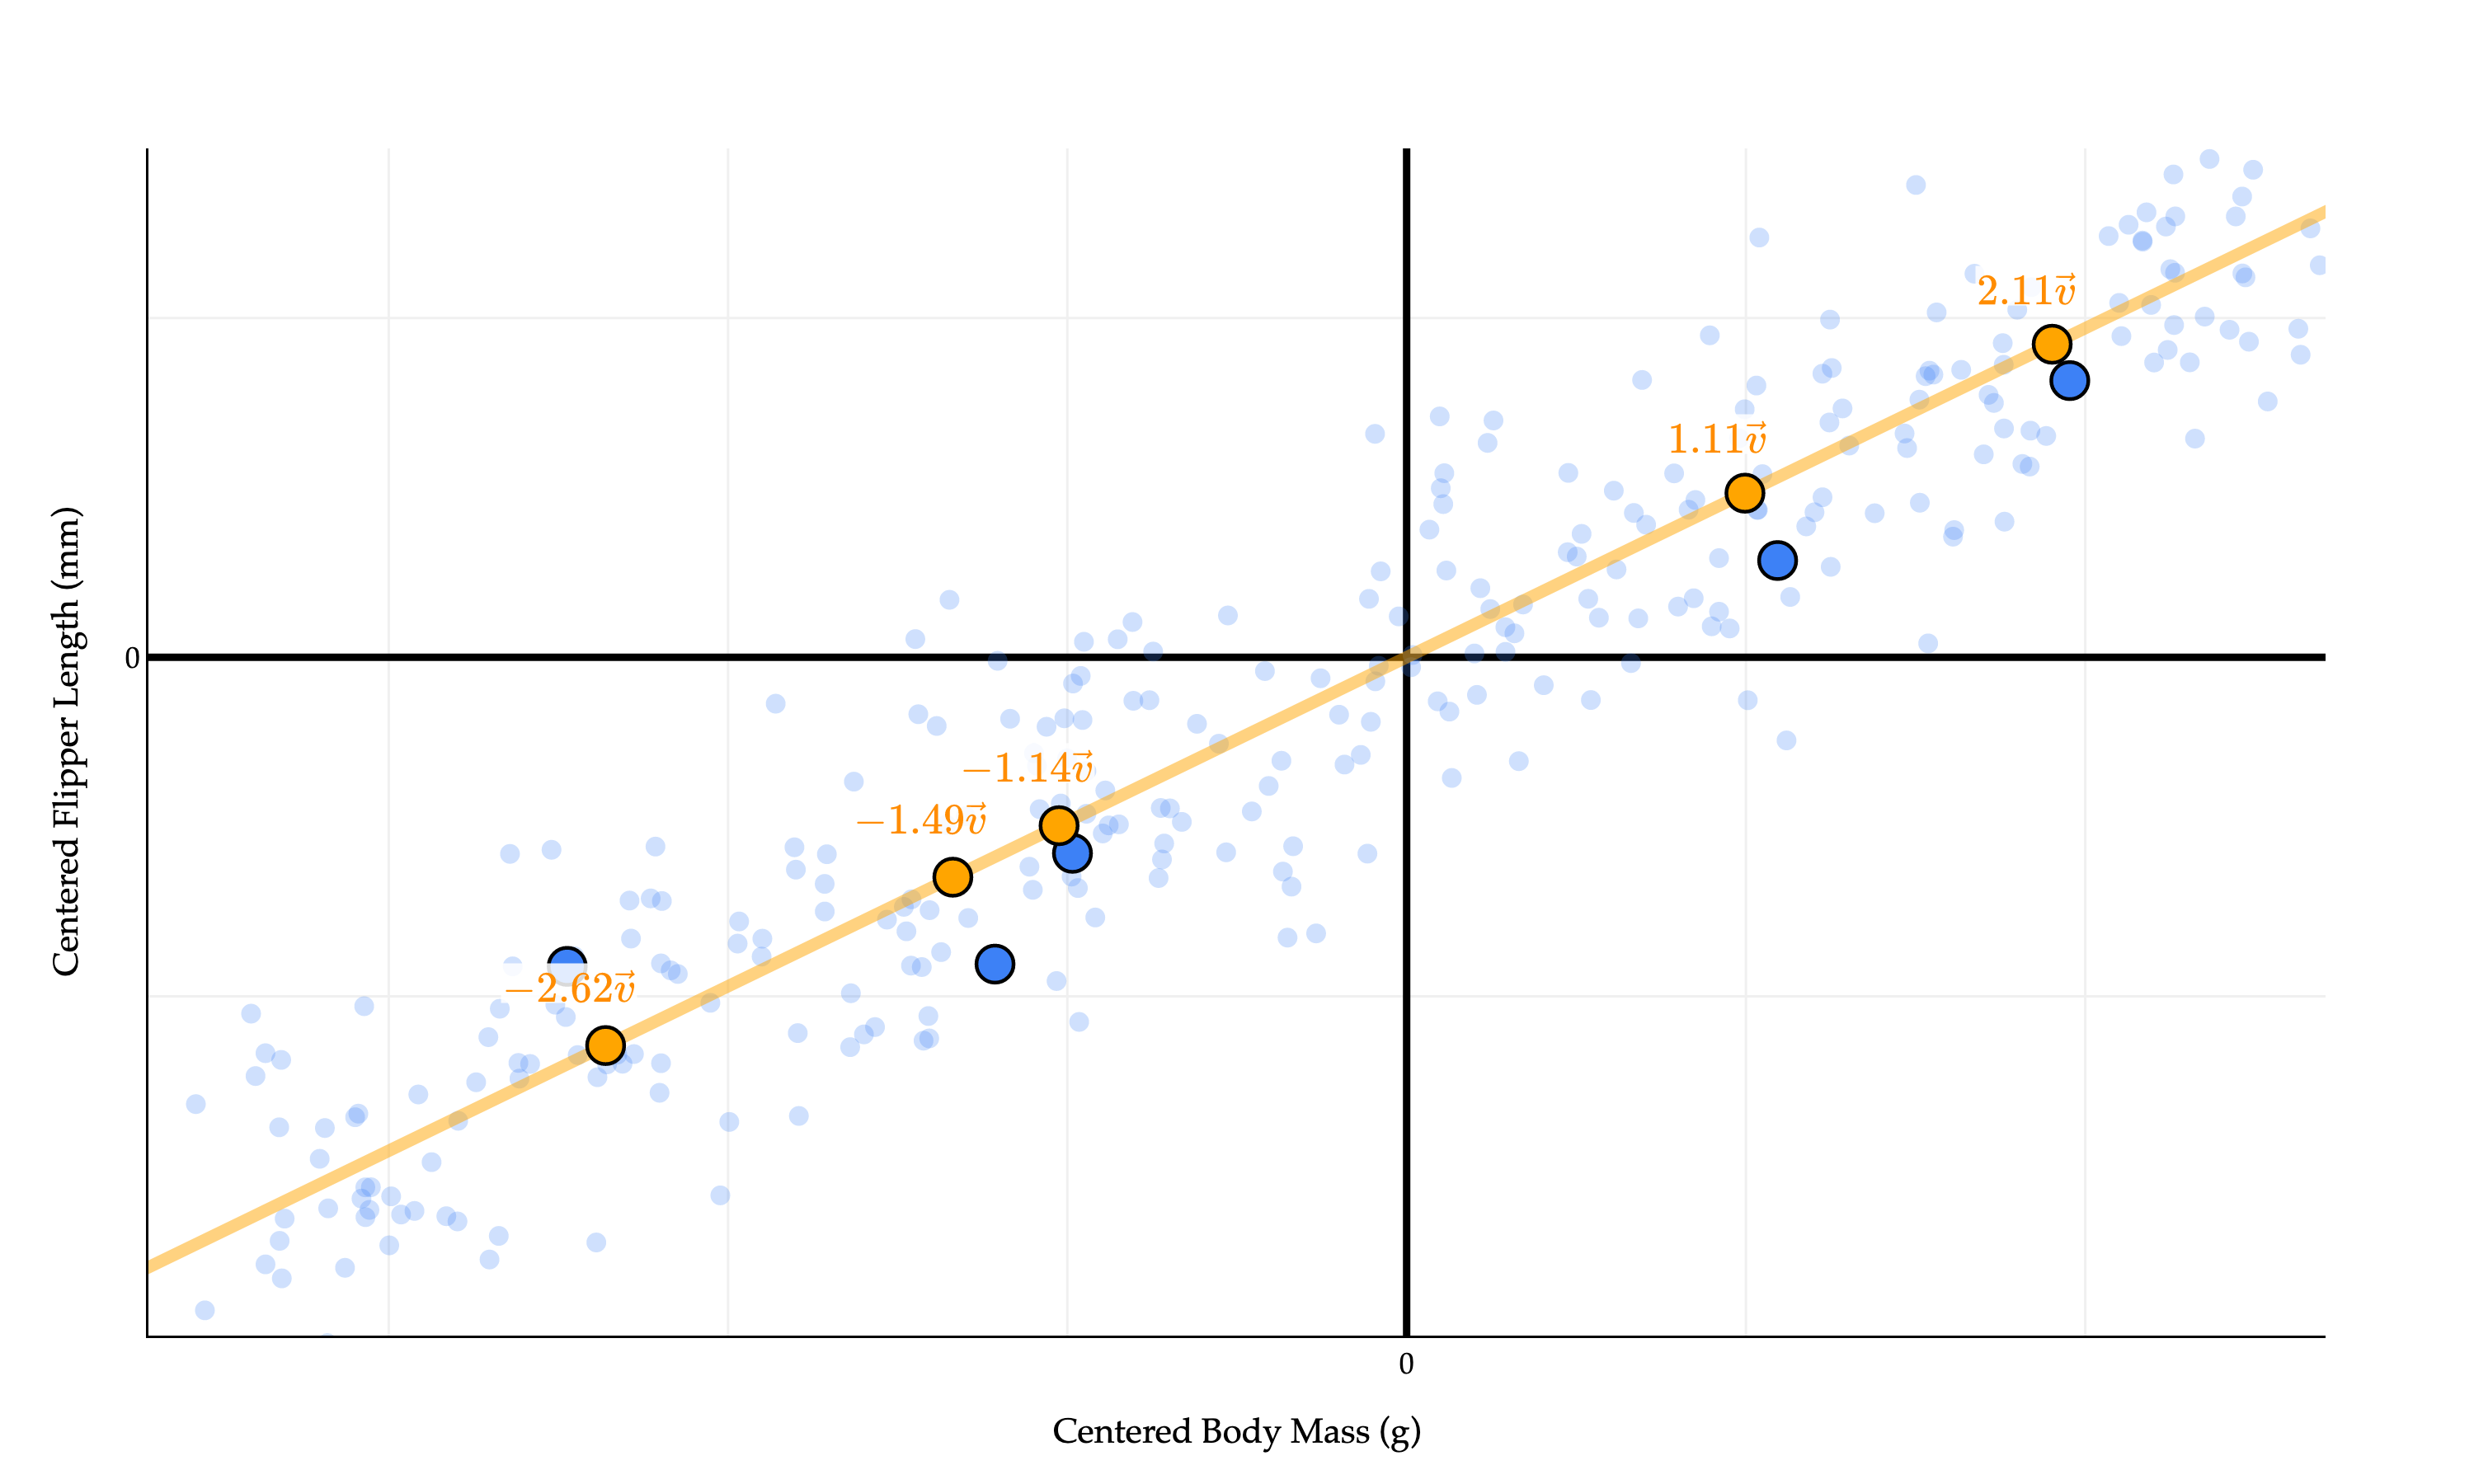

In [9]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# Use the same synthetic data as above, so the aspect is "fair"
np.random.seed(102)
num_points = 340
body_mass_g = np.random.uniform(2700, 6300, num_points)
m_true = 0.015
c_true = 120
noise = np.random.normal(0, 5, num_points)
flipper_length_mm = m_true * body_mass_g + c_true + noise

df = pd.DataFrame({
    'body_mass_g': body_mass_g,
    'flipper_length_mm': flipper_length_mm
})

# Standardize both columns to mean=0, std=1 for correct orthogonal aspect
df['body_mass_std'] = (df['body_mass_g'] - df['body_mass_g'].mean()) / df['body_mass_g'].std()
df['flipper_length_std'] = (df['flipper_length_mm'] - df['flipper_length_mm'].mean()) / df['flipper_length_mm'].std()
X = df[['body_mass_std', 'flipper_length_std']].values
X[:, 0] *= 2 # Scale x-axis for visual effect (as in original)

count_show = 5

# Fix the randomness: pick 25 random indices, keep correspondence for projections
rng = np.random.default_rng(51)
indices = rng.choice(len(X), replace=False, size=count_show)
X_subset = X[indices]   # shape (25, 2)

# Get best-fit direction using SVD/PCA
U, S, Vt = np.linalg.svd(X, full_matrices=False)
direction = Vt[0]
direction = direction / np.linalg.norm(direction)

# Project points in subset onto PCA line: scalar projections t_i and nearest points
ts = X_subset @ direction
proj_points = np.outer(ts, direction)  # shape (25,2)

# For labeling: pick 2 random points (from 25), annotate with their scalar times v
label_indices = rng.choice(count_show, size=count_show, replace=False)
label_indices = np.sort(label_indices)

# Plot setup with all standardized points (faded)
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=X[:,0], y=X[:,1],
    mode='markers',
    marker=dict(color="#3D81F6", size=8, opacity=0.25),
    showlegend=False,
    hoverinfo='skip'
))

# Scatter for the selected 25 points (emphasized)
fig.add_trace(go.Scatter(
    x=X_subset[:,0], y=X_subset[:,1],
    mode='markers',
    marker=dict(color="#3D81F6", size=13),
    name="25 Random Points",
    showlegend=False
))

# Principal component line (covers full range)
proj_min = X @ direction
pc_min, pc_max = proj_min.min(), proj_min.max()
pc_extend = 0.20 * (pc_max - pc_min)
line_range = np.array([pc_min - pc_extend, pc_max + pc_extend])
line_pts = np.outer(line_range, direction)

fig.add_trace(go.Scatter(
    x=line_pts[:,0], y=line_pts[:,1],
    mode='lines',
    line=dict(color="orange", width=5, dash='solid'),
    opacity=0.5,
    name="Principal Component"
))

# Scatter for projection points (small orange dots)
fig.add_trace(go.Scatter(
    x=proj_points[:,0], y=proj_points[:,1],
    mode='markers',
    marker=dict(color="orange", size=13),
    name="Projections",
    showlegend=False
))

# -----------------
# New Traces for the two annotated points (highlighted)
# -----------------

# Original Points (Blue with thin black outline)
fig.add_trace(go.Scatter(
    x=X_subset[label_indices, 0], y=X_subset[label_indices, 1],
    mode='markers',
    marker=dict(color="#3D81F6", size=15, line=dict(width=1.5, color='black')),
    name="Annotated Original Points",
    showlegend=False
))

# Projection Points (Orange with thin black outline)
fig.add_trace(go.Scatter(
    x=proj_points[label_indices, 0], y=proj_points[label_indices, 1],
    mode='markers',
    marker=dict(color="orange", size=15, line=dict(width=1.5, color='black')),
    name="Annotated Projection Points",
    showlegend=False
))

# # Draw orthogonal lines from each selected point to its projection
# for i in range(count_show):
#     fig.add_trace(go.Scatter(
#         x=[X_subset[i,0], proj_points[i,0]],
#         y=[X_subset[i,1], proj_points[i,1]],
#         mode='lines',
#         line=dict(color="#d81a60", width=2, dash='dot'),
#         showlegend=False,
#         hoverinfo='skip'
#     ))

# Annotate 2 random projection points with near-label (scalar times v)
arrow_offset = -0.2 # Smaller offset for "short arrows"
for label_i, idx in enumerate(label_indices):
    ti = ts[idx]
    px, py = proj_points[idx]
    coef = np.round(ti, 2)
    # Perpendicular direction (for offset): [-v2, v1]
    perp = np.array([-direction[1], direction[0]])
    perp = perp / np.linalg.norm(perp)
    label_offset = arrow_offset * perp
    ax = px + label_offset[0]
    ay = py + label_offset[1]
    # Formatting for - sign spacing like LaTeX, e.g. "-3.2 \vec v"
    if coef >= 0:
        label = rf"$-{coef} \vec{{v}}$"
    else:
        label = rf"${abs(coef)} \vec{{v}}$"
    fig.add_annotation(
        x=ax, y=ay,
        ax=ax, ay=ay,
        text=label,
        showarrow=True,
        arrowhead=6, # Changed arrowhead to 6
        arrowsize=0.7,
        arrowcolor="orange",
        arrowwidth=1.2,
        font=dict(family="Palatino Linotype, Palatino, serif", size=17, color='darkorange'),
        bgcolor="rgba(255,255,255,0.85)",
        opacity=1
    )

# Aspect ratio 1:1 to make orthogonality look correct
all_x = np.concatenate([X[:,0], proj_points[:,0]])
all_y = np.concatenate([X[:,1], proj_points[:,1]])
margin_x = 0.2 * (all_x.max() - all_x.min())
margin_y = 0.2 * (all_y.max() - all_y.min())
fig.update_xaxes(
    title='Standardized Body Mass',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    zeroline=True,
    zerolinewidth=3,
    zerolinecolor="black",
    range=[all_x.min()-margin_x, all_x.max()+margin_x],
    scaleanchor='y',  # lock aspect
    scaleratio=1
)
fig.update_yaxes(
    title='Standardized Flipper Length',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    zeroline=True,
    zerolinewidth=3,
    zerolinecolor="black",
    range=[all_y.min()-margin_y, all_y.max()+margin_y]
)

fig.update_layout(
    showlegend=False,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=1000,
    height=600,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    xaxis_range=[-3, 2],
    yaxis_range=[-2, 1.5],
    xaxis=dict(
        title='Centered Body Mass (g)',
        tickvals=[-3, -2, -1, 0, 1, 2],
        ticktext=['', '', '', 0, '', '']
    ),
    yaxis=dict(
        title='Centered Flipper Length (mm)',
        tickvals=[-2, -1, 0, 1, 1.5],
        ticktext=['', '', 0, '', '']
    )
)
fig.show(renderer='png', scale=3)

The values $\tilde x_1 \cdot \vec v, \tilde x_2 \cdot \vec v, \ldots, \tilde x_n \cdot \vec v$ - $\color{orange}-2.62$, $\color{orange}-1.49$, $\color{orange}-1.14$, $\color{orange}-1.11$, and $\color{orange}2.11$ above - describe the position of point $\tilde x_i$ on the line defined by $\vec v$. (I've highlighted just five of the points to make the picture less cluttered, but in reality every single blue point has a corresponding orange dot above!)

These coefficients on $\vec v$ can be thought of as positions on a number line.

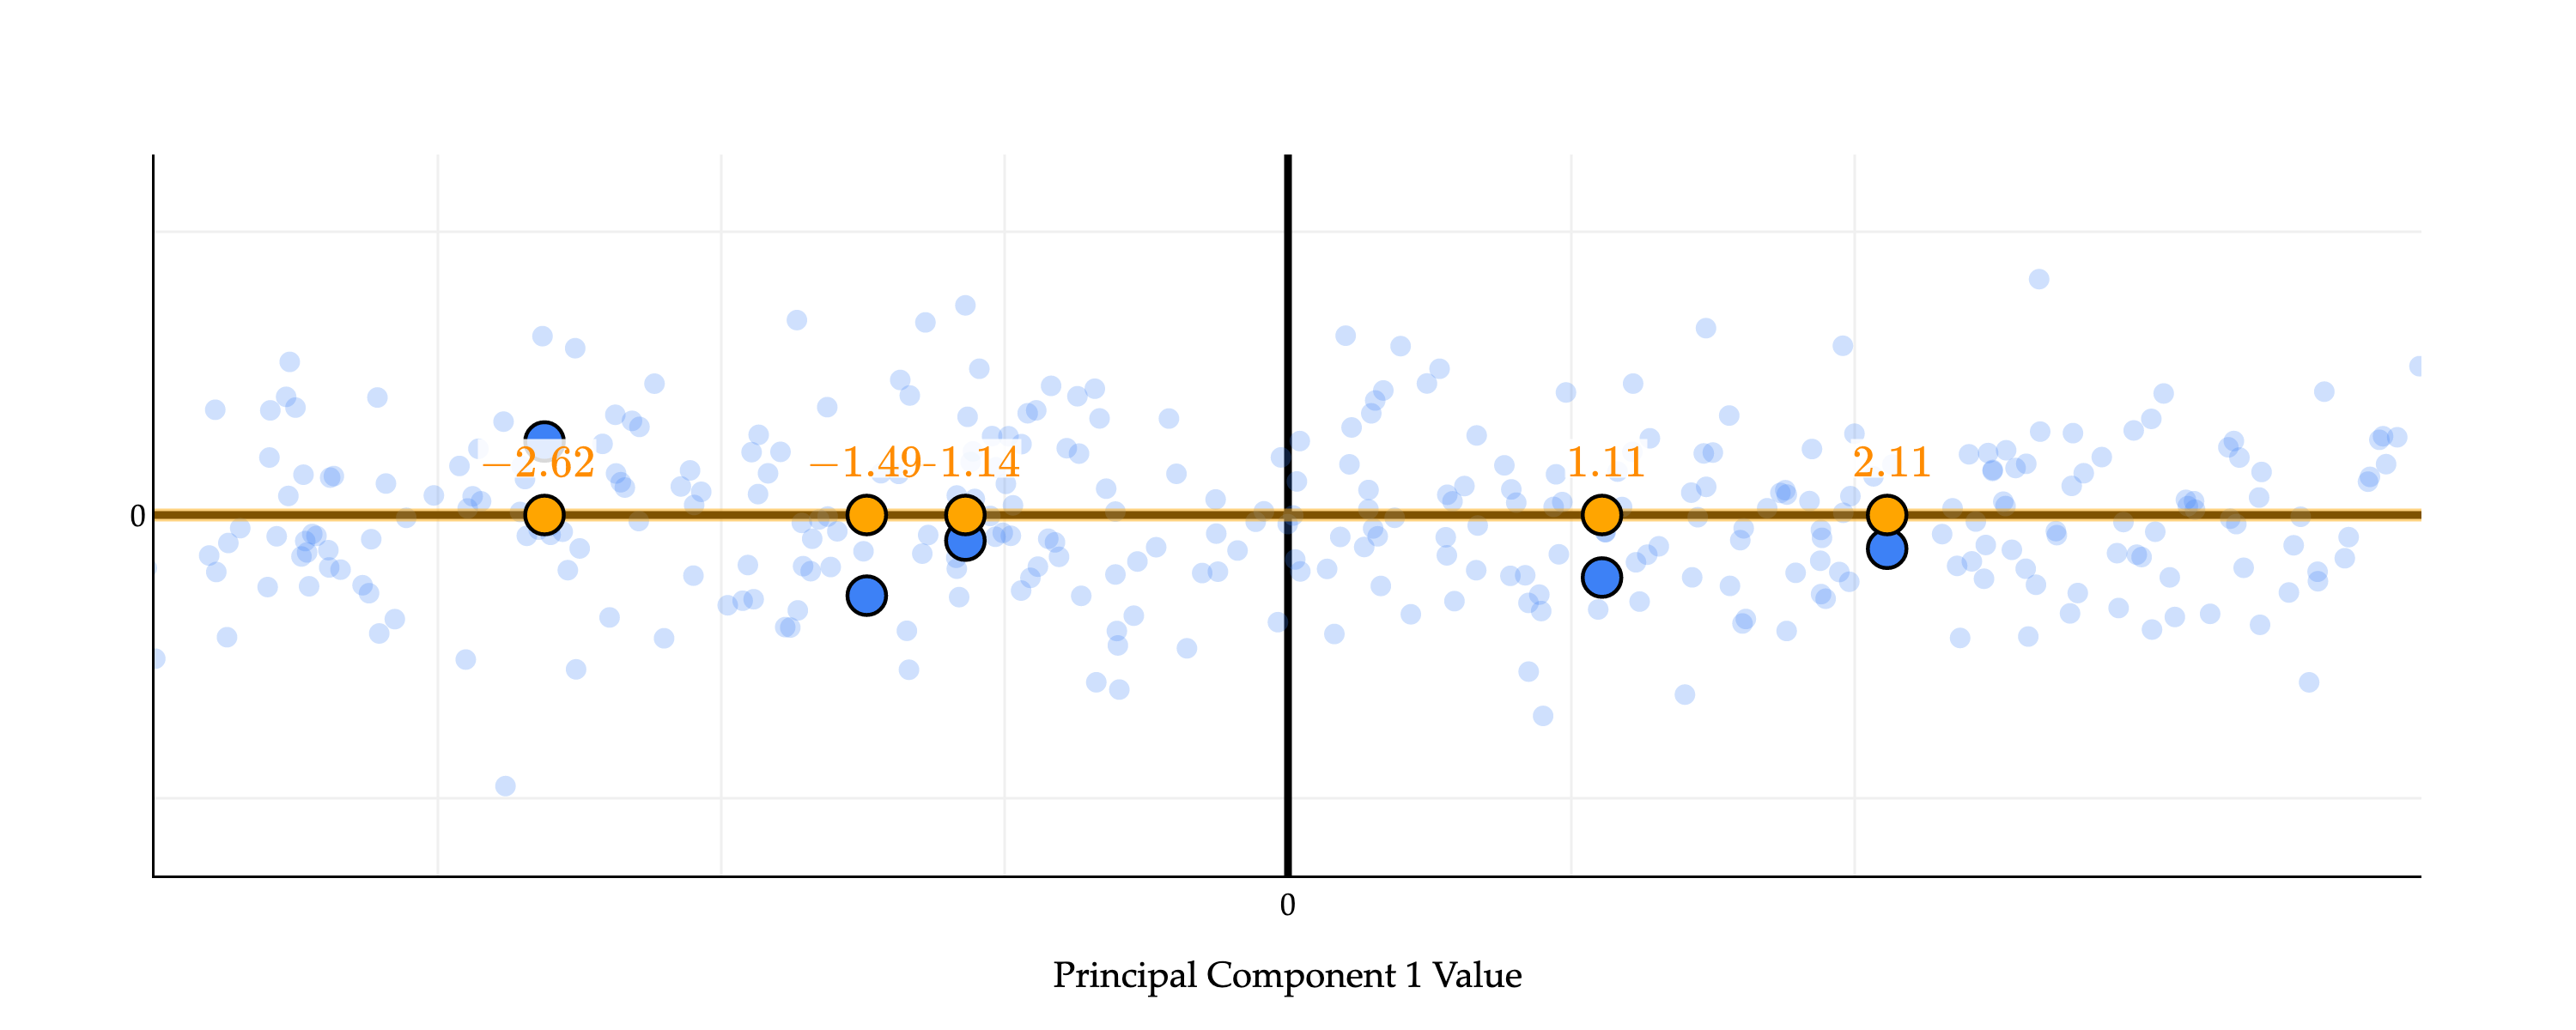

In [10]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# Use the same synthetic data as above, so the aspect is "fair"
np.random.seed(102)
num_points = 340
body_mass_g = np.random.uniform(2700, 6300, num_points)
m_true = 0.015
c_true = 120
noise = np.random.normal(0, 5, num_points)
flipper_length_mm = m_true * body_mass_g + c_true + noise

df = pd.DataFrame({
    'body_mass_g': body_mass_g,
    'flipper_length_mm': flipper_length_mm
})

# Standardize both columns to mean=0, std=1 for correct orthogonal aspect
df['body_mass_std'] = (df['body_mass_g'] - df['body_mass_g'].mean()) / df['body_mass_g'].std()
df['flipper_length_std'] = (df['flipper_length_mm'] - df['flipper_length_mm'].mean()) / df['flipper_length_mm'].std()
X = df[['body_mass_std', 'flipper_length_std']].values
X[:, 0] *= 2 # Scale x-axis for visual effect (as in original)

count_show = 5

# Fix the randomness: pick 5 random indices, keep correspondence for projections
rng = np.random.default_rng(51)
indices = rng.choice(len(X), replace=False, size=count_show)
X_subset = X[indices]   # shape (5, 2)

# Get best-fit direction using SVD/PCA
U, S, Vt = np.linalg.svd(X, full_matrices=False)
direction = Vt[0]
direction = -direction / np.linalg.norm(direction)

# Now rotate the whole dataset so that the principal component is horizontal
theta = np.arctan2(direction[1], direction[0])
R = np.array([[np.cos(-theta), -np.sin(-theta)],
              [np.sin(-theta),  np.cos(-theta)]])
X_rot = X @ R.T
X_subset_rot = X_subset @ R.T

# The "principal component direction" after rotation is along the x-axis: [1, 0]
# So projections onto the orange line map to (tx, 0)
ts = X_subset_rot[:, 0]  # The coordinate along principal component
proj_points_rot = np.column_stack([ts, np.zeros_like(ts)])

# For labeling: pick 5 random points (from 5), annotate with their scalar times v
label_indices = rng.choice(count_show, size=count_show, replace=False)
label_indices = np.sort(label_indices)

# Plot setup with all standardized points (faded)
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=X_rot[:,0], y=X_rot[:,1],
    mode='markers',
    marker=dict(color="#3D81F6", size=8, opacity=0.25),
    showlegend=False,
    hoverinfo='skip'
))

# Scatter for the selected 5 points (emphasized)
fig.add_trace(go.Scatter(
    x=X_subset_rot[:,0], y=X_subset_rot[:,1],
    mode='markers',
    marker=dict(color="#3D81F6", size=13),
    name="5 Random Points",
    showlegend=False
))

# Principal component line (horizontal, pass through origin), extended to cover full range
proj_min = X_rot[:, 0].min()
proj_max = X_rot[:, 0].max()
pc_extend = 0.20 * (proj_max - proj_min)
line_range = np.array([proj_min - pc_extend, proj_max + pc_extend])
line_pts = np.column_stack([line_range, [0, 0]])

fig.add_trace(go.Scatter(
    x=line_pts[:,0], y=line_pts[:,1],
    mode='lines',
    line=dict(color="orange", width=5, dash='solid'),
    opacity=0.5,
    name="Principal Component"
))

# Scatter for projection points (small orange dots)
fig.add_trace(go.Scatter(
    x=proj_points_rot[:,0], y=proj_points_rot[:,1],
    mode='markers',
    marker=dict(color="orange", size=13),
    name="Projections",
    showlegend=False
))

# Original Points (Blue with thin black outline)
fig.add_trace(go.Scatter(
    x=X_subset_rot[label_indices, 0], y=X_subset_rot[label_indices, 1],
    mode='markers',
    marker=dict(color="#3D81F6", size=15, line=dict(width=1.5, color='black')),
    name="Annotated Original Points",
    showlegend=False
))

# Projection Points (Orange with thin black outline)
fig.add_trace(go.Scatter(
    x=proj_points_rot[label_indices, 0], y=proj_points_rot[label_indices, 1],
    mode='markers',
    marker=dict(color="orange", size=15, line=dict(width=1.5, color='black')),
    name="Annotated Projection Points",
    showlegend=False
))

# # Draw orthogonal lines from each selected point to its projection
# for i in range(count_show):
#     fig.add_trace(go.Scatter(
#         x=[X_subset_rot[i,0], proj_points_rot[i,0]],
#         y=[X_subset_rot[i,1], proj_points_rot[i,1]],
#         mode='lines',
#         line=dict(color="#d81a60", width=2, dash='dot'),
#         showlegend=False,
#         hoverinfo='skip'
#     ))

# Annotate 5 random projection points with near-label (scalar times v)
arrow_offset = 0.2 # Smaller offset for "short arrows"
for label_i, idx in enumerate(label_indices):
    ti = ts[idx]
    px, py = proj_points_rot[idx]
    coef = np.round(ti, 2)
    # Perpendicular direction (for offset): [0,1] since the line is horizontal
    perp = np.array([0, 1])
    label_offset = arrow_offset * perp
    ax = px + label_offset[0]
    ay = py + label_offset[1]
    # Formatting for - sign spacing like LaTeX, e.g. "-3.2 \vec v"
    if coef >= 0:
        label = rf"${coef}$"
    else:
        label = rf"$-{abs(coef)}$"
    fig.add_annotation(
        x=ax, y=ay,
        ax=ax, ay=ay,
        text=label,
        showarrow=True,
        arrowhead=6, # Changed arrowhead to 6
        arrowsize=0.7,
        arrowcolor="orange",
        arrowwidth=1.2,
        font=dict(family="Palatino Linotype, Palatino, serif", size=17, color='darkorange'),
        bgcolor="rgba(255,255,255,0.85)",
        opacity=1
    )

# Aspect ratio 1:1 to make orthogonality look correct
all_x = np.concatenate([X_rot[:,0], proj_points_rot[:,0]])
all_y = np.concatenate([X_rot[:,1], proj_points_rot[:,1]])
margin_x = 0.2 * (all_x.max() - all_x.min())
margin_y = 0.2 * (all_y.max() - all_y.min())
fig.update_xaxes(
    title='Standardized Body Mass (Rotated)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    zeroline=True,
    zerolinewidth=3,
    zerolinecolor="black",
    range=[all_x.min()-margin_x, all_x.max()+margin_x],
    scaleanchor='y',  # lock aspect
    scaleratio=1
)
fig.update_yaxes(
    title='Standardized Flipper Length (Rotated)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    zeroline=True,
    zerolinewidth=3,
    zerolinecolor="black",
    range=[all_y.min()-margin_y, all_y.max()+margin_y]
)

fig.update_layout(
    showlegend=False,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=1000,
    height=400,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    xaxis_range=[-4, 4],
    yaxis_range=[-1, 1],
    xaxis=dict(
        title='Principal Component 1 Value',
        tickvals=[-3, -2, -1, 0, 1, 2],
        ticktext=['', '', '', 0, '', '']
    ),
    yaxis=dict(
        title='',
        tickvals=[-2, -1, 0, 1, 1.5],
        ticktext=['', '', 0, '', '']
    )
)
fig.show(renderer='png', scale=3)

Effectively, we've **rotated** the data so that the orange points are on the "new" $x$-axis. (Rotations... where have we heard of those before? The connection is coming.)

So, we have a grasp of what the values ${\color{orange}\tilde x_1 \cdot \vec v, \tilde x_2 \cdot \vec v, \ldots, \tilde x_n \cdot \vec v}$ describe. But why are they important?

The quantity we're trying to maximize,

$$\frac{1}{n} \sum_{i = 1}^n (\tilde x_i \cdot \vec v)^2$$

is the **variance** of the values $\color{orange}\tilde x_1 \cdot \vec v, \tilde x_2 \cdot \vec v, \ldots, \tilde x_n \cdot \vec v$. It's not immediately obvious why this is the case. Remember, the variance of a list of numbers is

$$\frac{1}{n} \sum_{i = 1}^n (\text{value}_i - \text{mean})^2$$

(I'm intentionally using vague notation to avoid conflating singular values with standard deviations.)

The quantity $\frac{1}{n} \sum_{i = 1}^n (\tilde x_i \cdot \vec v)^2$ resembles this definition of variance, but it doesn't seem to involve a subtraction by a mean. This is because the mean of $\tilde x_1 \cdot \vec v, \tilde x_2 \cdot \vec v, \ldots, \tilde x_n \cdot \vec v$ is 0! This seems to check out visually above: it seems that if we found the corresponding orange point for every single blue point, the orange points would be symmetrically distributed around 0.

:::{seealso} Proof that the mean of $\tilde x_1 \cdot \vec v, \tilde x_2 \cdot \vec v, \ldots, \tilde x_n \cdot \vec v$ is 0
:class: dropdown

Recall that each $\tilde x_i$ is a vector in $\mathbb{R}^d$ and corresponds to a **row** in $\tilde X$. The values $\tilde x_1 \cdot \vec v, \tilde x_2 \cdot \vec v, \ldots, \tilde x_n \cdot \vec v$ can all be computed at once through the matrix-vector product $\tilde X \vec v$ (remember that to multiply a matrix by a vector, we dot product the rows of the matrix with the vector).

The **columns** of $\tilde X$ each have a mean of 0. As we discovered in Activity 2, this means that

$$\tilde X^T \vec 1 = \begin{bmatrix} \text{sum of column 1 of } \tilde X \\ \text{sum of column 2 of } \tilde X \\ \vdots \\ \text{sum of column $d$ of } \tilde X\end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ \vdots \\ 0 \end{bmatrix} = \vec 0_{d}$$

if $\vec 1 \in \mathbb{R}^n$ is a vector of all ones.

So, what is the mean of the values $\tilde x_1 \cdot \vec v, \tilde x_2 \cdot \vec v, \ldots, \tilde x_n \cdot \vec v$? This mean, by definition, is $\frac{1}{n} \sum_{i = 1}^n \tilde x_i \cdot \vec v$, but this is equal to $\frac{1}{n} \left( (\tilde X \vec v)^T \vec 1 \right)$, once again, using the fact that the dot product with the ones vector is equivalent to summing the values of the other vector.

$$\frac{1}{n} \sum_{i = 1}^n (\tilde x_i \cdot \vec v) = \frac{1}{n} \left( (\tilde X \vec v)^T \vec 1 \right) = \frac{1}{n} \left( \vec v^T \tilde X^T \vec 1 \right) = \frac{1}{n} \left( \vec v^T \vec 0 \right) = 0$$

So, the mean of the values $\tilde x_1 \cdot \vec v, \tilde x_2 \cdot \vec v, \ldots, \tilde x_n \cdot \vec v$ is 0.
:::

Since the mean of the values $\tilde x_1 \cdot \vec v, \tilde x_2 \cdot \vec v, \ldots, \tilde x_n \cdot \vec v$ is 0, it is true that the quantity we're **maximizing** is the variance of the values $\tilde x_1 \cdot \vec v, \tilde x_2 \cdot \vec v, \ldots, \tilde x_n \cdot \vec v$, which I'll refer to as

$$\text{PV}(\vec v) = \frac{1}{n} \sum_{i = 1}^n (\tilde x_i \cdot \vec v)^2$$

PV stands for "projected variance"; it is the variance of the scalar projections of the rows of $\tilde X$ onto $\vec v$. This is non-standard notation, but I wanted to avoid calling this the "variance of $\vec v$", since it's not the variance of the components of $\vec v$.

### The Duality

We've stumbled upon a beautiful **duality** - that is, two equivalent ways to think about the same problem. Given a centered $n \times d$ matrix $\tilde X$ with rows $\tilde x_i \in \mathbb{R}^d$, the **most important direction** $\vec v$ is the one that
1. **Minimizes** the mean squared orthogonal error of projections onto it, $$J(\vec v) = \frac{1}{n} \sum_{i = 1}^n \lVert \tilde x_i - \vec p_i \rVert^2$$
1. Equivalently, **maximizes** the variance of the projected values $\tilde x_i \cdot \vec v$, i.e. **maximizes**

$$\text{PV}(\vec v) = \frac{1}{n} \sum_{i = 1}^n (\tilde x_i \cdot \vec v)^2$$

Minimizing orthogonal error is equivalent to maximizing variance: don't forget this. In the widget below, drag the slider to see this duality in action: the shorter the orthogonal errors tend to be, the more spread out the orange points tend to be (meaning their variance is large). When the orange points are close together, the orthogonal errors tend to be quite large.

In [11]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# Use the same synthetic data as above
np.random.seed(102)
num_points = 340
body_mass_g = np.random.uniform(2700, 6300, num_points)
m_true = 0.015
c_true = 120
noise = np.random.normal(0, 5, num_points)
flipper_length_mm = m_true * body_mass_g + c_true + noise

df = pd.DataFrame({
    'body_mass_g': body_mass_g,
    'flipper_length_mm': flipper_length_mm
})

df['body_mass_std'] = (df['body_mass_g'] - df['body_mass_g'].mean()) / df['body_mass_g'].std()
df['flipper_length_std'] = (df['flipper_length_mm'] - df['flipper_length_mm'].mean()) / df['flipper_length_mm'].std()
X = df[['body_mass_std', 'flipper_length_std']].values
X[:, 0] *= 2 # Scale x-axis for visual effect

count_show = 20

# Fix the randomness: pick 5 fixed indices
rng = np.random.default_rng(51)
indices = rng.choice(len(X), replace=False, size=count_show)
X_subset = X[indices]

# Get best-fit direction using SVD/PCA for computing optimal angle
U, S, Vt = np.linalg.svd(X, full_matrices=False)
opt_direction = Vt[0]
opt_direction = opt_direction / np.linalg.norm(opt_direction)
opt_theta = np.arctan2(opt_direction[1], opt_direction[0])  # in radians; in [-pi, pi]

# Helper for 360-degree range, always positive
def wrap_angle(theta):  # ensure [0, 2pi)
    return (theta + 2 * np.pi) % (2 * np.pi)

# For displaying the line as in plotly (a segment through the origin)
def make_line_pts(theta, vmin, vmax, extend=0.2):
    """Returns 2 points defining a line through origin with direction theta."""
    direction = np.array([np.cos(theta), np.sin(theta)])
    # Extend the min/max a bit for better plot
    range_min = vmin - extend * (vmax - vmin)
    range_max = vmax + extend * (vmax - vmin)
    xs = [range_min * direction[0], range_max * direction[0]]
    ys = [range_min * direction[1], range_max * direction[1]]
    return np.array([xs, ys]).T

# Function to project points onto a line at angle theta through (0,0)
def get_projections(X_pts, theta):
    direction = np.array([np.cos(theta), np.sin(theta)])
    direction = direction / np.linalg.norm(direction)
    ts = X_pts @ direction  # projections as scalars
    proj_points = np.outer(ts, direction)
    return proj_points

# Precompute range for line plotting (so all lines look visually similar)
vals_for_range = np.concatenate([X[:,0], X[:,1]])
vabs = np.max(np.abs(vals_for_range))
vmin, vmax = -vabs, vabs

# Slider construction
from plotly.subplots import make_subplots

# We'll build thetas so that index 0 is always the optimal, with slider ranging -360 to +360
n_steps = 181
thetas = np.linspace(-np.pi, np.pi, n_steps) + opt_theta  # centers thetas at opt_theta, from -360° to +360°
theta_labels = [f"{int(np.round(np.degrees(theta - opt_theta))):+d}°" for theta in thetas]  # ticks -360 to +360
# The optimal direction (opt_theta) is at index n_steps//2
start_ix = n_steps // 2

# Compute plot bounds
xlim = (-3, 2)
ylim = (-2, 1.5)
# axis ticks for styling
xticks = [-3, -2, -1, 0, 1, 2]
xticktext = ['', '', '', 0, '', '']
yticks = [-2, -1, 0, 1, 1.5]
yticktext = ['', '', 0, '', '']

# Make the figure with a first frame (at optimal PC direction)
def make_frame(theta):
    # Compute direction
    direction = np.array([np.cos(theta), np.sin(theta)])
    # Orange projection points for the 5
    proj_points = get_projections(X_subset, theta)
    # Line covering whole range
    line_seg = make_line_pts(theta, vmin, vmax)
    # Build traces
    traces = []
    # All standardized points, faded
    traces.append(go.Scatter(
        x=X[:,0], y=X[:,1],
        mode='markers',
        marker=dict(color="#3D81F6", size=8, opacity=0.25),
        showlegend=False,
        hoverinfo='skip'
    ))
    # Blue subset points (fixed)
    traces.append(go.Scatter(
        x=X_subset[:,0], y=X_subset[:,1],
        mode='markers',
        marker=dict(color="#3D81F6", size=13),
        name="5 Points",
        showlegend=False
    ))
    # Orange projection points
    traces.append(go.Scatter(
        x=proj_points[:,0], y=proj_points[:,1],
        mode='markers',
        marker=dict(color="orange", size=13),
        name="Projections",
        showlegend=False
    ))
    # Principal direction line
    traces.append(go.Scatter(
        x=line_seg[:,0], y=line_seg[:,1],
        mode='lines',
        line=dict(color="orange", width=5, dash='solid'),
        opacity=0.5,
        name="Direction"
    ))
    # Dashed lines for errors (one per blue point)
    for i in range(count_show):
        traces.append(go.Scatter(
            x=[X_subset[i,0], proj_points[i,0]],
            y=[X_subset[i,1], proj_points[i,1]],
            mode='lines',
            line=dict(color="#d81a60", width=2, dash='dot'),
            showlegend=False,
            hoverinfo='skip'
        ))
    return traces

# Build frames for animation
frames = []
for ti, theta in enumerate(thetas):
    traces = make_frame(theta)
    frame = go.Frame(
        data=traces,
        name=str(ti),
        traces=list(range(len(traces)))
    )
    frames.append(frame)

# Initial figure (at theta=0, so slider starts at optimal)
init_traces = make_frame(thetas[start_ix])
fig = go.Figure(data=init_traces, frames=frames)

# Set up slider to control theta, labeled -360 to +360, starting at 0
steps = []
for i, theta in enumerate(thetas):
    label = theta_labels[i]
    step = dict(
        method="animate",
        args=[
            [str(i)],
            {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}
        ],
        label=label
    )
    steps.append(step)

sliders = [dict(
    steps=steps,
    active=start_ix,
    transition={'duration': 0},
    x=0.2, y=0.01,
    currentvalue=dict(
        font=dict(size=18),
        prefix="θ (angle from optimum): ",
        visible=True, 
        xanchor='center'
    ),
    len=0.75
)]

fig.update_layout(
    sliders=sliders,
    showlegend=False,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=650,
    height=525,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    xaxis_range=list(xlim),
    yaxis_range=list(ylim),
    xaxis=dict(
        # title='Centered Body Mass (g)',
        tickvals=xticks,
        ticktext=xticktext,
        gridcolor='#f0f0f0',
        showline=True,
        linecolor="black",
        linewidth=1,
        zeroline=True,
        zerolinewidth=3,
        zerolinecolor="black"
    ),
    yaxis=dict(
        # title='Centered Flipper Length (mm)',
        tickvals=yticks,
        ticktext=yticktext,
        gridcolor='#f0f0f0',
        showline=True,
        linecolor="black",
        linewidth=1,
        zeroline=True,
        zerolinewidth=3,
        zerolinecolor="black"
    ),
    title="The shorter the <span style='color:#d81a60'>orthogonal errors</span> are, the more spread out the <span style='color:orange'>orange points</span> are!"
)

fig.show()

Note that the scalars $\tilde x_1 \cdot \vec v, \tilde x_2 \cdot \vec v, \ldots, \tilde x_n \cdot \vec v$ are just the components of the vector $\tilde X \vec v$! Multiplying $\tilde X$ by $\vec v$ returns a vector that contains the dot products of each row of $\tilde X$ (which are the $\tilde x_i$'s) with $\vec v$. This means that an equivalent formula for the projected variance is

$$\text{PV}(\vec v) = \frac{1}{n} \lVert \tilde X \vec v \rVert^2$$

This equivalent formulation will allow us to employ gradient rules from [Chapter 8.2](../08_gradients/02-gradients-matrix-vector-operations) to find the best direction.

### The Rayleigh Quotient

Our optimization problem is

$$\text{maximize } \lVert \tilde X \vec v \rVert^2 \quad \text{subject to } \lVert \vec v \rVert = 1$$

I've dropped the constant factor of $\frac{1}{n}$ for convenience; it won't change the answer.

This is a **constrained** optimization problem. The constraint matters because we're trying to find a direction, not an arbitrarily long vector: if we were allowed to scale $\vec v$ however we wanted, then $\lVert \tilde X \vec v \rVert^2$ could be made as large as we wanted just by multiplying $\vec v$ by a huge constant.

Constrained optimization problems are usually harder than unconstrained ones. In an unconstrained problem, a standard strategy is to compute a gradient and set it equal to $\vec 0$. With a constraint like $\lVert \vec v \rVert = 1$, that simple strategy does not apply directly, since the maximizer of $\lVert \tilde X \vec v \rVert^2$ subject to $\lVert \vec v \rVert = 1$ might not have a zero gradient.

Fortunately, this particular constrained problem can be converted into an equivalent unconstrained one. Define

$$f(\vec v) = \frac{\lVert \tilde X \vec v \rVert^2}{\lVert \vec v \rVert^2}$$

for all non-zero vectors $\vec v$. This function is called a **Rayleigh quotient**, as we discussed briefly in [Chapter 9.6](../09_eigenvalues_and_eigenvectors/06-rayleigh-quotient.ipynb).

Why is maximizing $f(\vec v)$ with no constraints equivalent to maximizing $\lVert \tilde X \vec v \rVert^2$ subject to $\lVert \vec v \rVert = 1$? The short answer is that $f(\vec v)$ is invariant to scaling $\vec v$ by a constant factor. To see what I mean, suppose that $c$ is a non-zero constant. Then,

$$f(c\vec v) = \frac{\lVert \tilde X (c\vec v) \rVert^2}{\lVert c\vec v \rVert^2} = \frac{c^2 \lVert \tilde X \vec v \rVert^2}{c^2 \lVert \vec v \rVert^2} = f(\vec v)$$

So $f(\vec v)$ depends only on direction, not on length. Equivalently, every non-zero $\vec v$ gives the same value as the corresponding unit vector $\frac{\vec v}{\lVert \vec v \rVert}$, who makes the denominator in $f(\vec v)$ equal to 1. That means maximizing $\lVert \tilde X \vec v \rVert^2$ subject to $\lVert \vec v \rVert = 1$ is equivalent to maximizing $f(\vec v)$ over all non-zero vectors $\vec v$.

This is easier, because once the constraint has been absorbed into the denominator, we can treat $f$ as an ordinary vector-to-scalar function and find its critical points by setting the gradient equal to $\vec 0$.

In our setting,

$$f(\vec v) = \frac{\lVert \tilde X \vec v \rVert^2}{\lVert \vec v \rVert^2} = \frac{\vec v^T \tilde X^T \tilde X \vec v}{\vec v^T \vec v}$$

To find the critical points of $f$, it is cleaner to rewrite it as a product:

$$f(\vec v) = \left( \lVert \tilde X \vec v \rVert^2 \right) \left( \lVert \vec v \rVert^{-2} \right)$$

Let

$$g(\vec v) = \lVert \tilde X \vec v \rVert^2 = \vec v^T \tilde X^T \tilde X \vec v \\ h(\vec v) = \lVert \vec v \rVert^{-2} = (\vec v^T \vec v)^{-1}$$

so that $f(\vec v) = g(\vec v) h(\vec v)$. Since $\tilde X^T \tilde X$ is symmetric,

$$\nabla g(\vec v) = 2 \tilde X^T \tilde X \vec v$$

Also, by the chain rule,

$$\nabla h(\vec v) = -2 \frac{\vec v}{\lVert \vec v \rVert^4}$$

Now the product rule gives

$$\nabla f(\vec v) = {\color{3d81f6} g(\vec v)} {\color{orange} \nabla h(\vec v)} +  {\color{d81a60} h(\vec v)} {\color{004d40} \nabla g(\vec v)}$$

which simplifies to

\begin{align*}
\nabla f(\vec v) &= {\color{3d81f6} g(\vec v)} {\color{orange} \nabla h(\vec v)} +  {\color{d81a60} h(\vec v)} {\color{004d40} \nabla g(\vec v)} \\
&= {\color{3d81f6} \vec v^T \tilde X^T \tilde X \vec v} {\color{orange} \left(-2 \frac{\vec v}{\lVert \vec v \rVert^4}\right)} + {\color{d81a60} (\vec v^T \vec v)^{-1}} {\color{004d40} \left(2 \tilde X^T \tilde X \vec v\right)} \\
&= -2 \frac{\vec v^T \tilde X^T \tilde X \vec v}{\lVert \vec v \rVert^4} \vec v + 2 \frac{\tilde X^T \tilde X \vec v}{\lVert \vec v \rVert^2} \\
&= -2 \frac{f(\vec v)}{\lVert \vec v \rVert^2} \vec v + 2 \frac{\tilde X^T \tilde X \vec v}{\lVert \vec v \rVert^2} \\
&= \frac{2}{\lVert \vec v \rVert^2} \left( \tilde X^T \tilde X \vec v - f(\vec v) \vec v \right)
\end{align*}

If $\vec v$ maximizes $f(\vec v)$, then it must be a critical point, so $\nabla f(\vec v) = \vec 0$. Therefore,

$$\tilde X^T \tilde X \vec v - f(\vec v) \vec v = \vec 0$$

which means

$$\tilde X^T \tilde X \vec v = f(\vec v) \vec v$$

**This says exactly that $\vec v$ is an eigenvector of $\tilde X^T \tilde X$, and that its eigenvalue is $f(\vec v)$.** If $\vec v$ maximizes – or minimizes – $f(\vec v)$, then it must be an eigenvector of $\tilde X^T \tilde X$.

So, to make $f(\vec v)$ as large as possible, we should choose the eigenvector whose eigenvalue is as large as possible. In other words, **the best direction is the eigenvector of $\tilde X^T \tilde X$ corresponding to its largest eigenvalue!**

:::{note} Alternative Derivation
:class: dropdown
There is another way to prove the same result that uses the spectral theorem more directly.

Let $\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_d$ be the eigenvalues of $\tilde X^T \tilde X$, and let $\vec v_1, \vec v_2, \ldots, \vec v_d$ be corresponding unit eigenvectors. Since $\tilde X^T \tilde X$ is symmetric, these eigenvectors form an orthonormal basis of $\mathbb{R}^d$.

Now suppose $\lVert \vec v \rVert = 1$. Then

$$\vec v = c_1 \vec v_1 + c_2 \vec v_2 + \cdots + c_d \vec v_d, \qquad c_1^2 + c_2^2 + \cdots + c_d^2 = 1$$

Using the fact that $\tilde X^T \tilde X \vec v_i = \lambda_i \vec v_i$, we get

\begin{align*}
f(\vec v)
&= \vec v^T \tilde X^T \tilde X \vec v \\
&= \lambda_1 c_1^2 + \lambda_2 c_2^2 + \cdots + \lambda_d c_d^2
\end{align*}

So $f(\vec v)$ is a weighted average of the eigenvalues of $\tilde X^T \tilde X$. A weighted average can never be larger than the largest value being averaged, so $f(\vec v) \leq \lambda_1$, with equality when $\vec v = \vec v_1$ (or $-\vec v_1$). This again shows that the maximizing direction is the eigenvector corresponding to the largest eigenvalue.
:::

What does this really mean geometrically?


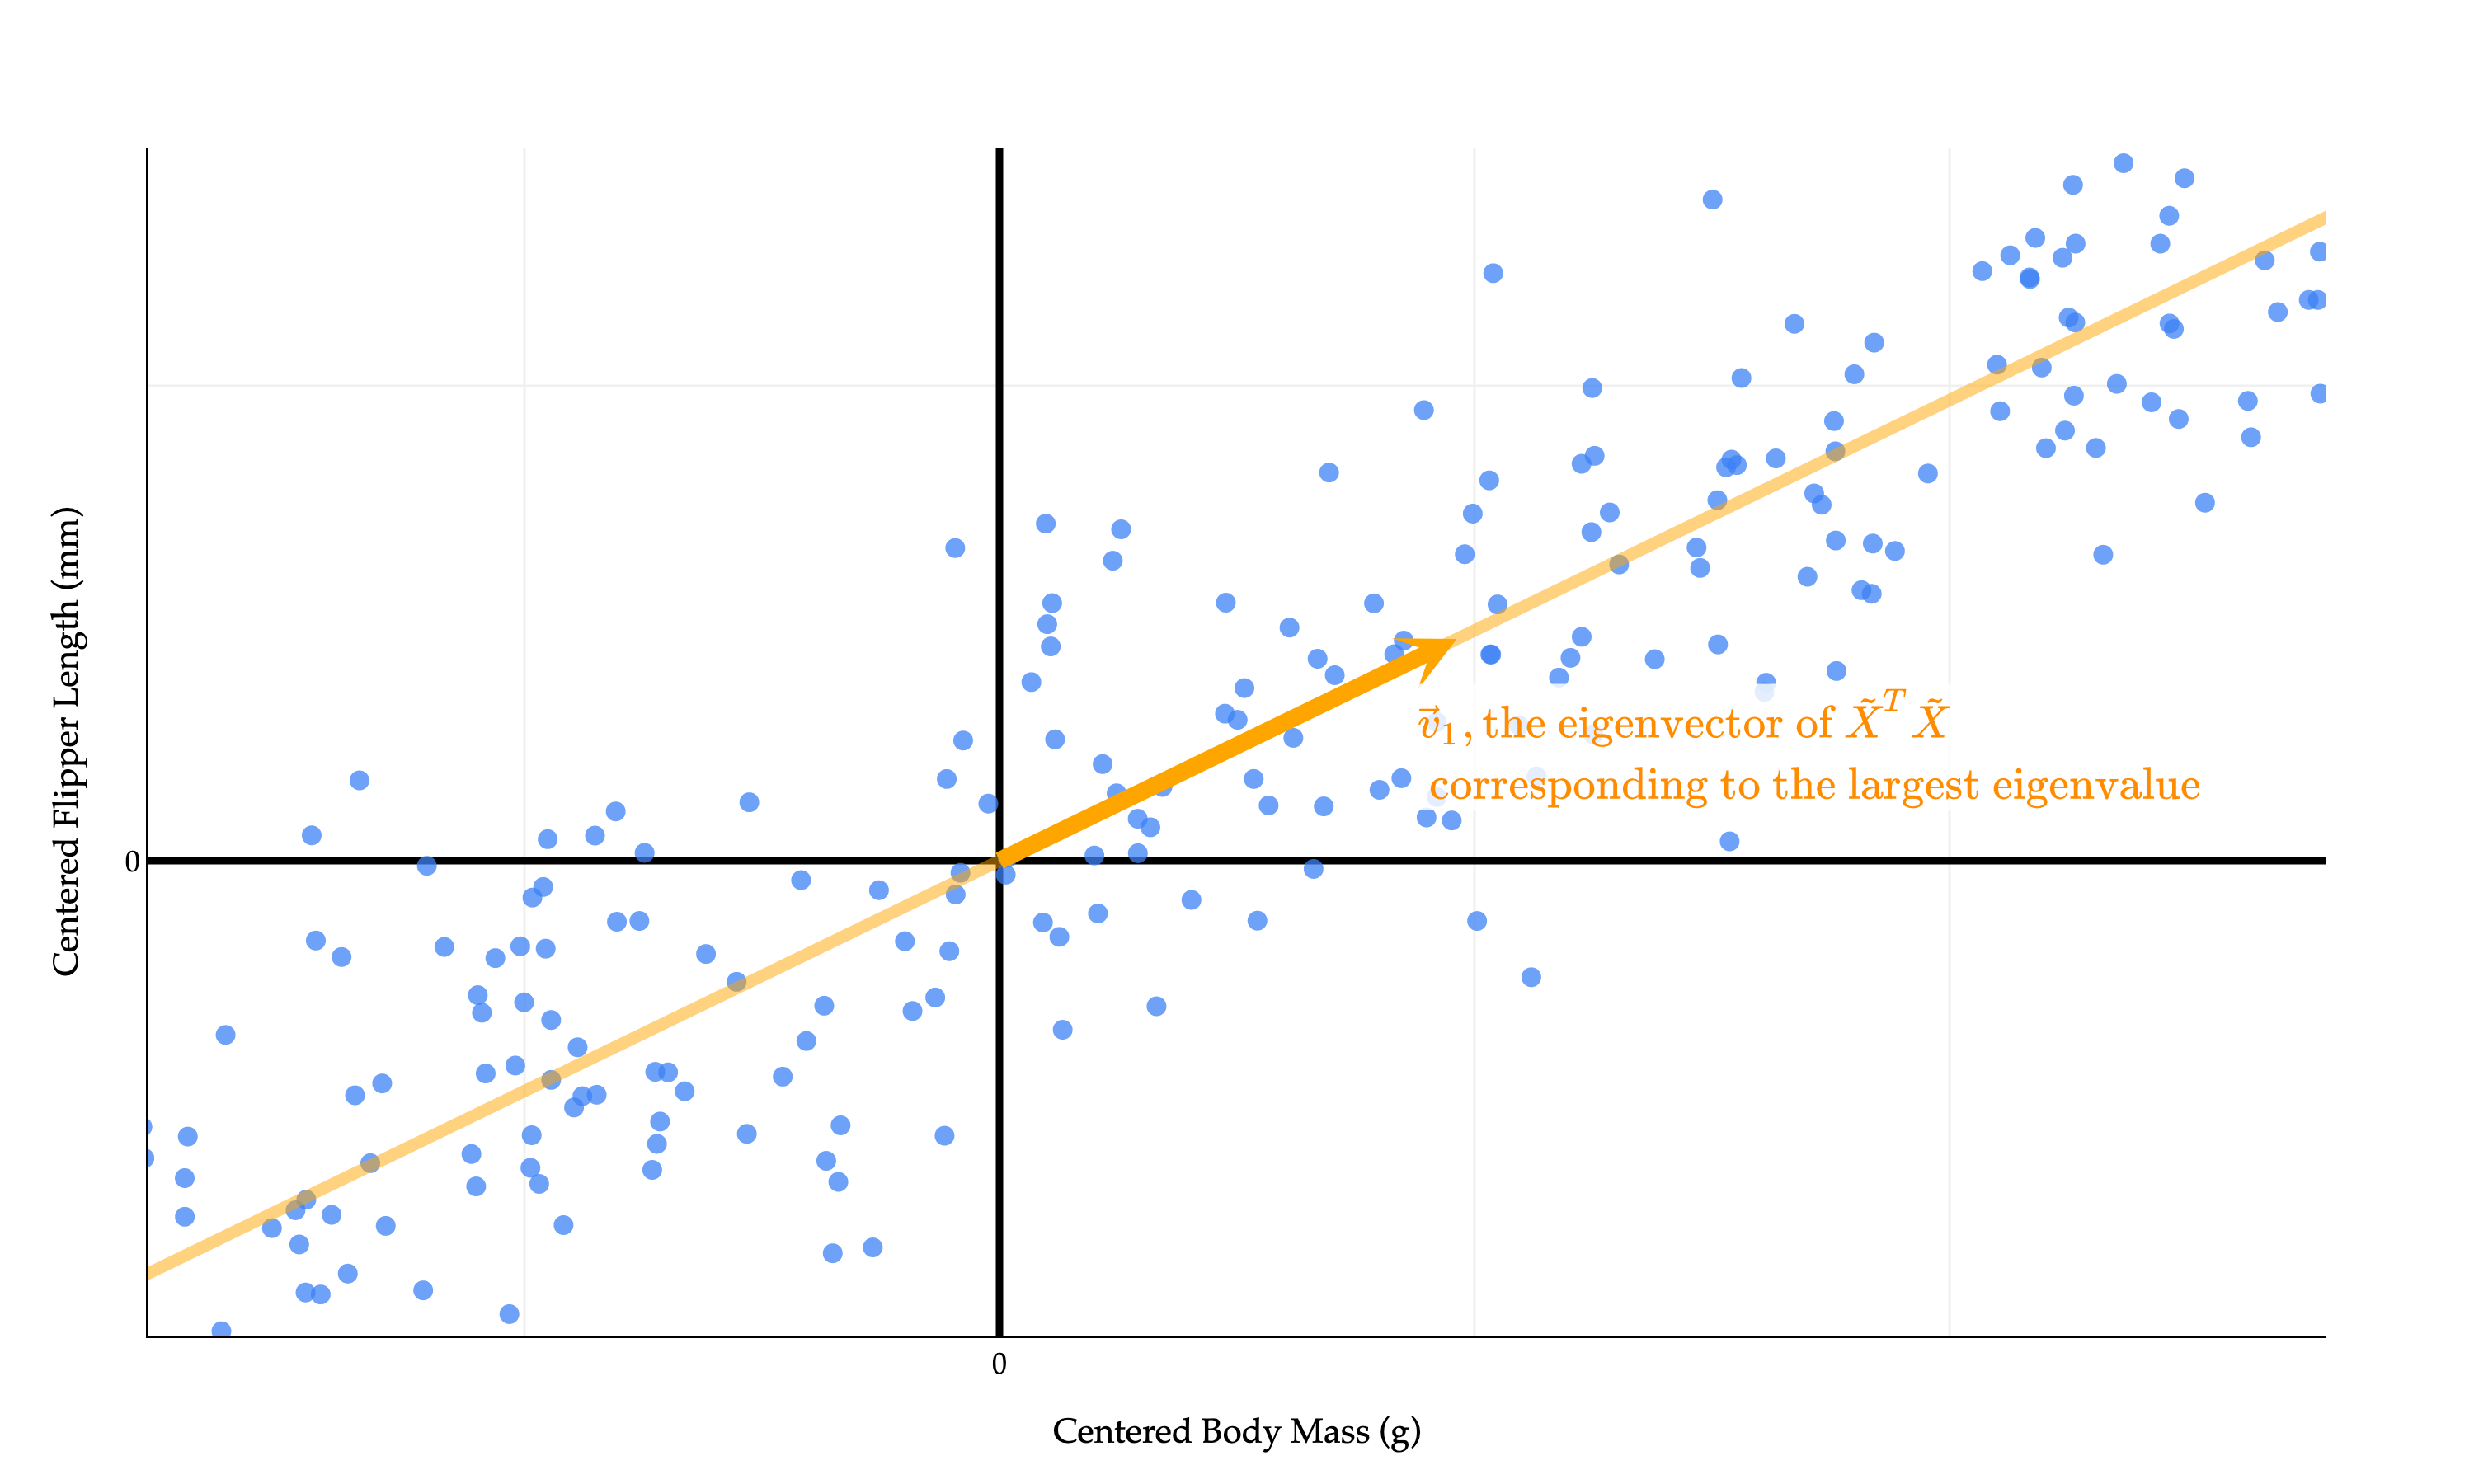

In [12]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# Use the same synthetic data as above, so the aspect is "fair"
np.random.seed(102)
num_points = 340
body_mass_g = np.random.uniform(2700, 6300, num_points)
m_true = 0.015
c_true = 120
noise = np.random.normal(0, 5, num_points)
flipper_length_mm = m_true * body_mass_g + c_true + noise

df = pd.DataFrame({
    'body_mass_g': body_mass_g,
    'flipper_length_mm': flipper_length_mm
})

# Standardize both columns to mean=0, std=1 for correct orthogonal aspect
df['body_mass_std'] = (df['body_mass_g'] - df['body_mass_g'].mean()) / df['body_mass_g'].std()
df['flipper_length_std'] = (df['flipper_length_mm'] - df['flipper_length_mm'].mean()) / df['flipper_length_mm'].std()
X = df[['body_mass_std', 'flipper_length_std']].values
X[:, 0] *= 2 # Scale x-axis for visual effect (as in original)

# Get best-fit direction using SVD/PCA
U, S, Vt = np.linalg.svd(X, full_matrices=False)
direction = Vt[0]
direction = direction / np.linalg.norm(direction)

# Plot setup with all standardized points (higher opacity)
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=X[:,0], y=X[:,1],
    mode='markers',
    marker=dict(color="#3D81F6", size=8, opacity=0.75),
    showlegend=False,
    hoverinfo='skip'
))

# Principal component line (covers full range, faded)
proj_min = X @ direction
pc_min, pc_max = proj_min.min(), proj_min.max()
pc_extend = 0.20 * (pc_max - pc_min)
line_range = np.array([pc_min - pc_extend, pc_max + pc_extend])
line_pts = np.outer(line_range, direction)

fig.add_trace(go.Scatter(
    x=line_pts[:,0], y=line_pts[:,1],
    mode='lines',
    line=dict(color="orange", width=5, dash='solid'),
    opacity=0.5,
    name="Principal Component"
))

# Draw a unit vector along the principal component, centered at (0, 0)
unit_length = 1   # visibly "unit", can be adjusted if needed
vec_start = np.array([0.0, 0.0])
vec_end = -direction * unit_length

fig.add_trace(go.Scatter(
    x=[vec_start[0], vec_end[0]],
    y=[vec_start[1], vec_end[1]],
    mode="lines",
    line=dict(color="orange", width=7),
    marker=dict(color="orange", size=[0, 24]), # marker at tip
    showlegend=False
))

# Add arrowhead using annotation (to visually mark vector tip)
fig.add_annotation(
    x=vec_end[0]-0.07*direction[0], # a bit before tip, so arrow doesn't overshoot marker
    y=vec_end[1]-0.07*direction[1],
    ax=vec_start[0],
    ay=vec_start[1],
    xref="x", yref="y", axref="x", ayref="y",
    text="",
    arrowhead=3,
    arrowsize=1.3,
    arrowwidth=3,
    arrowcolor="orange",
    standoff=0,
    opacity=1,
    showarrow=True
)

# Annotate the vector with label \vec v_1
# Place label a little past the tip in the same direction
label_offset = 0.15
fig.add_annotation(
    x=vec_end[0] + label_offset * direction[0] * (-6),
    y=vec_end[1] + 3 * label_offset * direction[1],
    text=r"$\vec{v}_1, \text{the eigenvector of } \tilde X^T \tilde X \\ \text{ corresponding to the largest eigenvalue}$",
    showarrow=False,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        size=40,
        color='darkorange'
    ),
    bgcolor="rgba(255,255,255,0.82)",
    opacity=1
)

# Aspect ratio 1:1 to make orthogonality look correct
margin_x = 0.2 * (X[:,0].max() - X[:,0].min())
margin_y = 0.2 * (X[:,1].max() - X[:,1].min())
fig.update_xaxes(
    title='Standardized Body Mass',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    zeroline=True,
    zerolinewidth=3,
    zerolinecolor="black",
    range=[X[:,0].min()-margin_x, X[:,0].max()+margin_x],
    scaleanchor='y',  # lock aspect
    scaleratio=1
)
fig.update_yaxes(
    title='Standardized Flipper Length',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    zeroline=True,
    zerolinewidth=3,
    zerolinecolor="black",
    range=[X[:,1].min()-margin_y, X[:,1].max()+margin_y]
)

fig.update_layout(
    showlegend=False,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=1000,
    height=600,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    xaxis_range=[-1, 2],
    yaxis_range=[-1, 1.5],
    xaxis=dict(
        title='Centered Body Mass (g)',
        tickvals=[-3, -2, -1, 0, 1, 2],
        ticktext=['', '', '', 0, '', '']
    ),
    yaxis=dict(
        title='Centered Flipper Length (mm)',
        tickvals=[-2, -1, 0, 1, 1.5],
        ticktext=['', '', 0, '', '']
    )
)
fig.show(renderer='png', scale=3)

It says that the line that maximizes the variance of the projected data - which is also the line that minimizes the mean squared orthogonal error - is **spanned by the eigenvector of $\tilde X^T \tilde X$ corresponding to the largest eigenvalue of $\tilde X^T \tilde X$.**

So, we've solved the "best direction" problem. But what can we do with it? And how does this relate to the singular value decomposition, which we discussed in Chapters 10.1 and 10.2 but didn't touch at all here? Let's keep reading...